Loading data... (This may take a moment for large files)
-> Detected Quadrature Outputs (CK0, CK90, CK180, CK270).

Calculating Jitter...
--- Jitter Results ---
Mean Frequency: 30.00 kHz
RMS Jitter:     5856.07 ps
Pk-Pk Jitter:   34177.63 ps

Calculating Quadrature Phase Match...
--- 4-Phase Quadrature Results ---
0°   -> 90°:   90.023° (Error: 0.023°)
90°  -> 180°:  89.989° (Error: 0.011°)
180° -> 270°:  89.993° (Error: 0.007°)
270° -> 0°:    89.995° (Error: 0.005°)
MAX PHASE ERROR: 0.023°

Calculating Frequency Data...
Extracting Phase Error from Jitter...
--- Phase Noise Results ---
Carrier Freq:       30.00 kHz
Phase Noise @ 1 kHz: -92.65 dBc/Hz

Plotting zoomed quadrature waveforms...


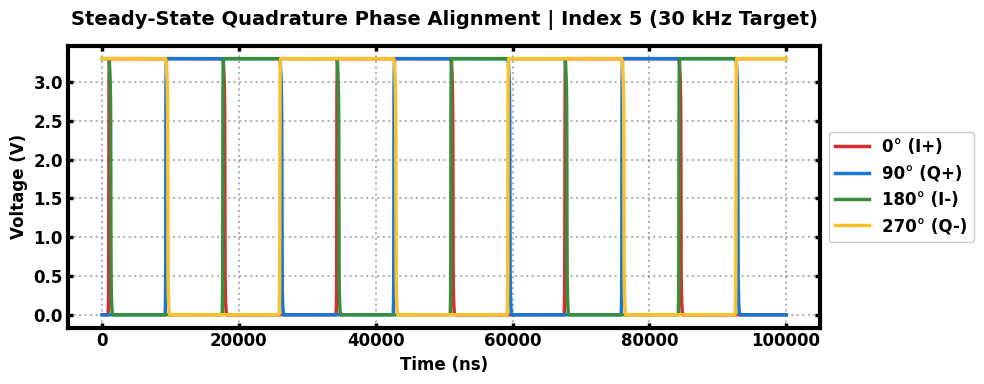

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
#TB 1
FILE_PATH = '../sim_data/tb1_3.txt' 
VCO_COLUMN_NAME = 'ck0' 
LOCK_TIME_THRESHOLD = 13e-3
STOP_TIME_THRESHOLD = 40.8e-3

#TB 2
#FILE_PATH = '../sim_data/tb2_7.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 71e-6
#STOP_TIME_THRESHOLD = 150e-6

#TB 3
#FILE_PATH = '../sim_data/tb3_4.txt'
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 85e-6
#STOP_TIME_THRESHOLD = 150e-6

#FILE_PATH = '../sim_data/tb3_7.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 50e-6
#STOP_TIME_THRESHOLD = 100e-6

#TB 4   
#FILE_PATH = '../sim_data/tb4.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 120e-6
#STOP_TIME_THRESHOLD = 150e-6

#TB 5
#FILE_PATH = '../sim_data/tb5_2.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 10e-6
#STOP_TIME_THRESHOLD = 150e-6

#FILE_PATH = '../sim_data/tb5.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 110e-6
#STOP_TIME_THRESHOLD = 150e-6

#FILE_PATH = '../sim_data/tb5_3.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 10e-6
#STOP_TIME_THRESHOLD = 180e-6

#Model + PFD
#FILE_PATH = '../sim_data/tb_PLL_PFD_model2.txt' 
#VCO_COLUMN_NAME = 'vco_out' 
#LOCK_TIME_THRESHOLD = 3e-6
#STOP_TIME_THRESHOLD = 100e-6

#Open-Loop VCO
#FILE_PATH = '../sim_data/tb_quadrature_vco_free_running.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 0e-6
#STOP_TIME_THRESHOLD = 30e-6

#FILE_PATH = '../sim_data/tb_PLL_model.txt' 
#VCO_COLUMN_NAME = 'vco_out' 


print("Loading data... (This may take a moment for large files)")
try:
    df = pd.read_csv(FILE_PATH, sep=r'\s+')
except FileNotFoundError:
    print(f"ERROR: Could not find file at {FILE_PATH}")
    sys.exit()

# Ensure the dataframe columns are lowercase for easier matching
df.columns = df.columns.str.lower()

# Slice the data to ONLY include the stable locked region
# NOTE: Ensure your simulation ran long enough! (> 0.1s for 20 kHz, ~100us for 300 MHz)

df = df[(df['time'] > LOCK_TIME_THRESHOLD) & (df['time'] < STOP_TIME_THRESHOLD)]

if df.empty:
    print(f"ERROR: The dataframe is empty. No data exists after {LOCK_TIME_THRESHOLD} seconds.")
    sys.exit()

t = df['time'].values
try:
    v_ck0 = df[VCO_COLUMN_NAME].values
except KeyError:
    print(f"ERROR: Column '{VCO_COLUMN_NAME}' not found.")
    sys.exit()

# Auto-detect Quadrature Outputs
has_quadrature = all(col in df.columns for col in ['ck90', 'ck180', 'ck270'])
if has_quadrature:
    print("-> Detected Quadrature Outputs (CK0, CK90, CK180, CK270).")
    v_ck90  = df['ck90'].values
    v_ck180 = df['ck180'].values
    v_ck270 = df['ck270'].values
else:
    print("-> Single-ended output detected. Skipping quadrature phase check.")

# ==========================================
# 2. Edge Detection Helpers
# ==========================================
v_mid = 1.65 

def get_rising_edges(v_sig, t_sig, threshold):
    crossings = np.where((v_sig[:-1] < threshold) & (v_sig[1:] >= threshold))[0]
    edges = []
    for idx in crossings:
        t1, t2 = t_sig[idx], t_sig[idx+1]
        v1, v2 = v_sig[idx], v_sig[idx+1]
        edges.append(t1 + (t2 - t1) * (threshold - v1) / (v2 - v1))
    return np.array(edges)

def calc_phase_diff(edges_lead, edges_lag, period_array):
    delta_t = []
    for t_lead in edges_lead:
        future_edges = edges_lag[edges_lag > t_lead]
        if len(future_edges) > 0:
            delta_t.append(future_edges[0] - t_lead)
    
    delta_t = np.array(delta_t)
    min_len = min(len(delta_t), len(period_array))
    delta_t = delta_t[:min_len]
    p_array = period_array[:min_len]
    return np.mean((delta_t / p_array) * 360.0)

# ==========================================
# 3. Jitter & Quadrature Calculation
# ==========================================
print("\nCalculating Jitter...")
edges_0 = get_rising_edges(v_ck0, t, v_mid)

if len(edges_0) < 2:
    print("ERROR: Less than two clock edges were detected. Simulation time is too short.")
    sys.exit()

periods = np.diff(edges_0)
if len(periods) == 0:
    print("ERROR: Period array is empty. Cannot calculate jitter.")
    sys.exit()

mean_period = np.mean(periods)
rms_jitter = np.std(periods)
pk_pk_jitter = np.max(periods) - np.min(periods)

# Dynamic Frequency Scaling Logic
fc = 1.0 / mean_period
if fc < 1e6:
    freq_scale = 1e3
    freq_label = "kHz"
    target_offset = 1e3   # Benchmark at 1 kHz for low frequency
    plot_xlim_left = 10   # Start plot at 10 Hz
else:
    freq_scale = 1e6
    freq_label = "MHz"
    target_offset = 1e6   # Benchmark at 1 MHz for high frequency
    plot_xlim_left = 10e3 # Start plot at 10 kHz

# Dynamic Time Unit Scaling for Jitter Plot
if rms_jitter > 1e-9:
    time_scale = 1e9
    time_label = "ns"
else:
    time_scale = 1e12
    time_label = "ps"

print(f"--- Jitter Results ---")
print(f"Mean Frequency: {fc / freq_scale:.2f} {freq_label}")
print(f"RMS Jitter:     {rms_jitter * 1e12:.2f} ps")
print(f"Pk-Pk Jitter:   {pk_pk_jitter * 1e12:.2f} ps")

if has_quadrature:
    print("\nCalculating Quadrature Phase Match...")
    edges_90  = get_rising_edges(v_ck90, t, v_mid)
    edges_180 = get_rising_edges(v_ck180, t, v_mid)
    edges_270 = get_rising_edges(v_ck270, t, v_mid)

    phase_0_90   = calc_phase_diff(edges_0, edges_90, periods)
    phase_90_180 = calc_phase_diff(edges_90, edges_180, periods)
    phase_180_270= calc_phase_diff(edges_180, edges_270, periods)
    phase_270_0  = calc_phase_diff(edges_270, edges_0, periods)

    err_0_90   = abs(phase_0_90 - 90.0)
    err_90_180 = abs(phase_90_180 - 90.0)
    err_180_270= abs(phase_180_270 - 90.0)
    err_270_0  = abs(phase_270_0 - 90.0)
    max_error = max(err_0_90, err_90_180, err_180_270, err_270_0)

    print(f"--- 4-Phase Quadrature Results ---")
    print(f"0°   -> 90°:   {phase_0_90:.3f}° (Error: {err_0_90:.3f}°)")
    print(f"90°  -> 180°:  {phase_90_180:.3f}° (Error: {err_90_180:.3f}°)")
    print(f"180° -> 270°:  {phase_180_270:.3f}° (Error: {err_180_270:.3f}°)")
    print(f"270° -> 0°:    {phase_270_0:.3f}° (Error: {err_270_0:.3f}°)")
    print(f"MAX PHASE ERROR: {max_error:.3f}°")

# ==========================================
# 4. Phase Noise & FFT Calculation
# ==========================================
print("\nCalculating Frequency Data...")

# --- A. Power Spectrum (Voltage FFT) ---
dt_uniform = t[1] - t[0]
N = len(v_ck0)
fft_complex = np.fft.fft(v_ck0)
fft_freqs = np.fft.fftfreq(N, d=dt_uniform)

fft_mag_dB = 20 * np.log10(np.abs(fft_complex) / np.max(np.abs(fft_complex)) + 1e-20)
pos_fft_idx = fft_freqs > 0
fft_freqs_pos = fft_freqs[pos_fft_idx]
fft_mag_pos_dB = fft_mag_dB[pos_fft_idx]

# --- B. True Phase Noise Calculation (From Time Interval Error) ---
print("Extracting Phase Error from Jitter...")
ideal_edges = edges_0[0] + np.arange(len(edges_0)) * mean_period
tie_array = edges_0 - ideal_edges  # Raw Time Interval Error

# --- THE FIX: Center the TIE to align the eye diagram perfectly on the y-axis (x=0) ---
tie_mean = np.mean(tie_array)
tie_array = tie_array - tie_mean
ideal_edges = ideal_edges + tie_mean  # Shift ideal clock to match the center of mass
# -------------------------------------------------------------------------------------

f_sample = 1.0 / mean_period 
# Force full array for maximum low-frequency resolution
nperseg_phase = len(tie_array)

offset_freqs, psd_phase = signal.welch(tie_array * 2 * np.pi * fc, fs=f_sample, window='hann', nperseg=nperseg_phase)
phase_noise_dBc = 10 * np.log10((psd_phase / 2) + 1e-20)

valid_indices = offset_freqs > 0
offset_freqs = offset_freqs[valid_indices]
phase_noise_dBc = phase_noise_dBc[valid_indices]

closest_idx = np.argmin(np.abs(offset_freqs - target_offset))
benchmark_label = "1 MHz" if target_offset == 1e6 else f"{target_offset/1e3:.0f} kHz"

print(f"--- Phase Noise Results ---")
print(f"Carrier Freq:       {fc / freq_scale:.2f} {freq_label}")
print(f"Phase Noise @ {benchmark_label}: {phase_noise_dBc[closest_idx]:.2f} dBc/Hz\n")

# ==========================================
# 5. Quadrature Time-Domain Plotting
# ==========================================
if has_quadrature:
    print("Plotting zoomed quadrature waveforms...")
    
    # Isolate exactly 3 clock periods at the end of the simulation
    zoom_start = t[-1] - (3 * mean_period)
    zoom_mask = (t >= zoom_start)
    
    # Scale time axis dynamically for the plot
    t_plot = (t[zoom_mask] - zoom_start) * time_scale 
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot all four phases with distinct, professional colors
    ax.plot(t_plot, v_ck0[zoom_mask], label='0° (I+)', color='#D32F2F', linewidth=2.5)   # Red
    ax.plot(t_plot, v_ck90[zoom_mask], label='90° (Q+)', color='#1976D2', linewidth=2.5)  # Blue
    ax.plot(t_plot, v_ck180[zoom_mask], label='180° (I-)', color='#388E3C', linewidth=2.5) # Green
    ax.plot(t_plot, v_ck270[zoom_mask], label='270° (Q-)', color='#FBC02D', linewidth=2.5) # Yellow
    
    # --- UPDATED TITLE ---
    # Dynamically formats the calculated frequency (e.g., 300) and unit (e.g., MHz)
    target_freq_rounded = round(fc / freq_scale)
    ax.set_title(f'Steady-State Quadrature Phase Alignment | Index 5 ({target_freq_rounded} {freq_label} Target)', pad=15, fontsize=14, fontweight='bold')
    
    ax.set_xlabel(f'Time ({time_label})', fontweight='bold')
    ax.set_ylabel('Voltage (V)', fontweight='bold')
    ax.grid(True, linestyle=':', linewidth=1.5, color='black', alpha=0.3)
    
    # Place legend outside the main wave area to prevent covering data
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), framealpha=1)
    
    plt.tight_layout()
    plt.savefig('quadrature_zoomed.png', dpi=300, transparent=True)
    plt.show()

Processing edges for Oscilloscope Eye Diagram overlay...


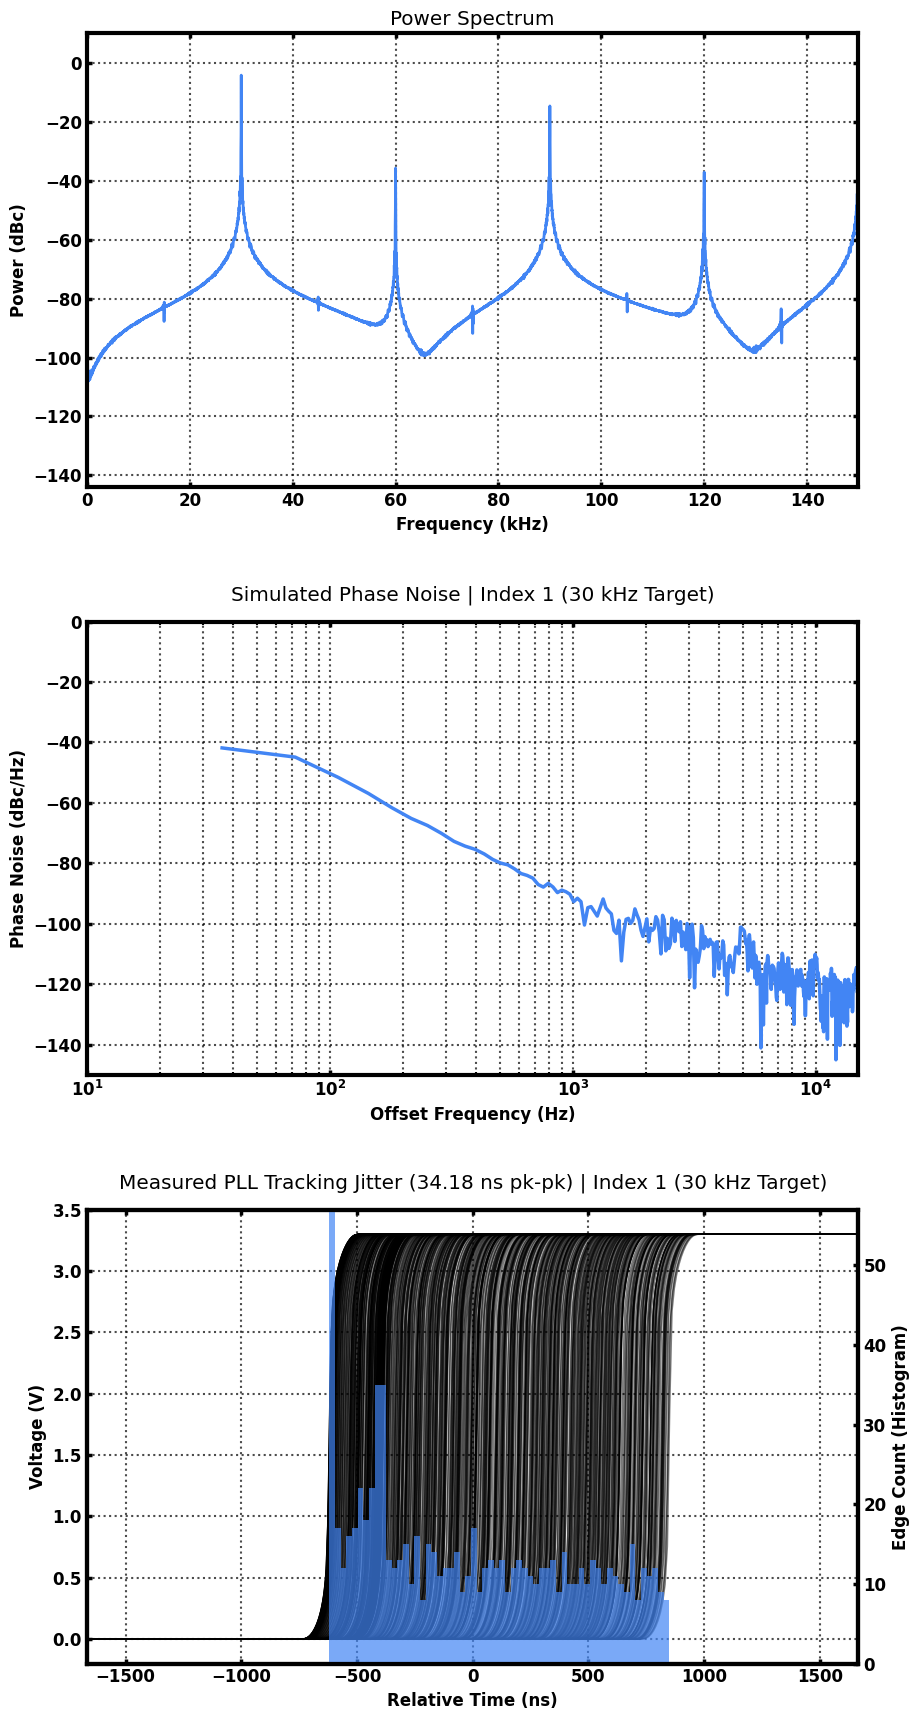

In [15]:
# ==========================================
# 5. Plotting
# ==========================================
plt.rcParams.update({
    'axes.linewidth': 3,
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
    'xtick.major.width': 2.5,
    'ytick.major.width': 2.5,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'font.size': 12
})

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# --- Plot 1: Power Spectrum ---
ax1.plot(fft_freqs_pos / freq_scale, fft_mag_pos_dB, color='#4285F4', linewidth=2)
ax1.set_title('Power Spectrum')
ax1.set_xlabel(f'Frequency ({freq_label})')
ax1.set_ylabel('Power (dBc)')
ax1.grid(True, which='both', linestyle=':', linewidth=1.5, color='black', alpha=0.7)

min_power = np.min(fft_mag_pos_dB)
ax1.set_ylim(bottom=np.floor(min_power / 10)*8, top=10)
ax1.set_xlim(left=0, right=(fc / freq_scale) * 5)
ax1.margins(x=0) 

# --- Plot 2: Simulated Phase Noise ---
ax2.semilogx(offset_freqs, phase_noise_dBc, color='#4285F4', linewidth=2.5)
ax2.set_title(fr'Simulated Phase Noise | Index 1 ({target_freq_rounded} {freq_label} Target)', pad=15)
ax2.set_xlabel('Offset Frequency (Hz)')
ax2.set_ylabel('Phase Noise (dBc/Hz)')
ax2.grid(True, which='both', linestyle=':', linewidth=1.5, color='black', alpha=0.7)

ax2.set_xlim(left=plot_xlim_left, right=offset_freqs[-1])
ax2.set_ylim(top=0)

# --- Plot 3: Oscilloscope Persistence Overlay & Histogram ---
ax3.set_title(fr'Measured PLL Tracking Jitter ({pk_pk_jitter * time_scale:.2f} {time_label} pk-pk) | Index 1 ({target_freq_rounded} {freq_label} Target)', pad=15)
ax3.set_xlabel(f'Relative Time ({time_label})')
ax3.set_ylabel('Voltage (V)')
ax3.grid(True, linestyle=':', linewidth=1.5, color='black', alpha=0.7)

print("Processing edges for Oscilloscope Eye Diagram overlay...")

zoom_window = max(pk_pk_jitter * 5, mean_period * 0.05)
num_traces = min(len(edges_0), 2000)

# Trigger on the IDEAL clock edge to expose the actual Time Interval Error
for i in range(1, num_traces - 1): 
    t_ideal = ideal_edges[i]
    
    # Slice the continuous time and voltage arrays around the IDEAL edge
    mask = (t > t_ideal - zoom_window) & (t < t_ideal + zoom_window)
    t_slice = t[mask]
    v_slice = v_ck0[mask]
    
    # Normalize the time slice so the IDEAL crossing is exactly at 0
    t_relative = (t_slice - t_ideal) * time_scale
    
    # Plot the smeared actual edges
    ax3.plot(t_relative, v_slice, color='black', alpha=0.5, linewidth=1)

ax3.set_xlim([-zoom_window * time_scale, zoom_window * time_scale])
ax3.set_ylim([-0.2, 3.5]) 

# Add the Jitter Histogram at the bottom via twinx
ax4 = ax3.twinx()
# Center the histogram bins exactly on the TIE deviations
ax4.hist(tie_array * time_scale, bins=60, color='#4285F4', alpha=0.7, density=False)
ax4.set_ylabel('Edge Count (Histogram)')

max_count = np.max(np.histogram(tie_array * time_scale, bins=60)[0])
ax4.set_ylim([0, max_count]) 

plt.tight_layout(pad=3.0)
plt.show()

PLL SIMULATION ANALYSIS - INDEX 4

Loading simulation data...

Transient samples in analysis window: 2999999
Detected quadrature outputs: CK0, CK90, CK180, CK270

Extracting CK0 rising edges...
Detected rising edges: 7650

--- CLOCK FREQUENCY ---
Mean period: 3.921498047e-09 s
Mean frequency: 255.0046 MHz
Number of periods: 7649

Results will be saved to:
/foss/designs/synchronos-chipathon-2026/designs/libs/scripts/pll_characterization/results/index_4_255p00_MHz

--- PERIOD JITTER ---
RMS period jitter: 499.2861 fs
Pk-pk period jitter: 7468.9657 fs
Minimum period error: -931.8123 fs
Maximum period error: 6537.1534 fs
Automatic histogram bins: 323

--- TIME INTERVAL ERROR ---
RMS TIE: 31.2134 ps
Pk-pk TIE: 121.0329 ps

Calculating quadrature phase alignment...

--- QUADRATURE PHASE RESULTS ---
CK0 -> CK90:   90.0000 deg (error 0.0000 deg)
CK90 -> CK180: 89.9998 deg (error 0.0002 deg)
CK180 -> CK270:90.0002 deg (error 0.0002 deg)
CK270 -> CK0:  90.0001 deg (error 0.0001 deg)
Maximum phas

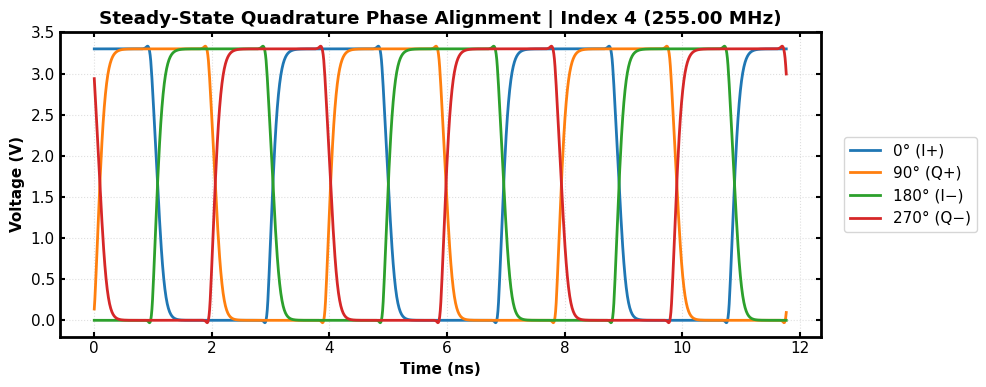

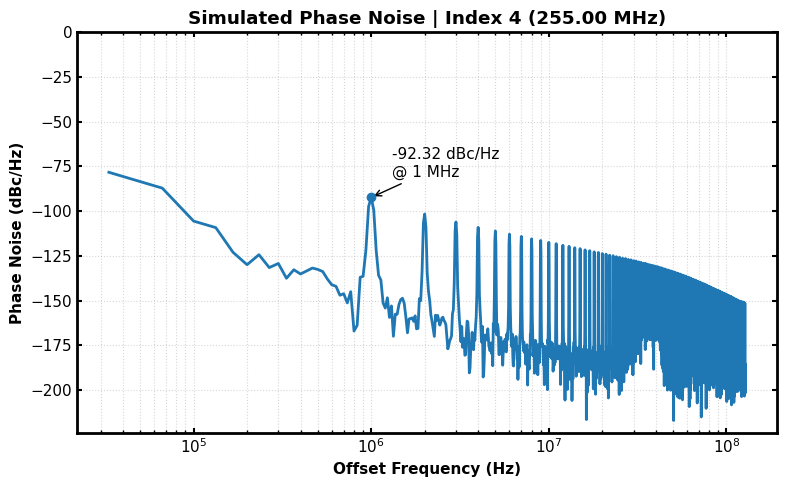

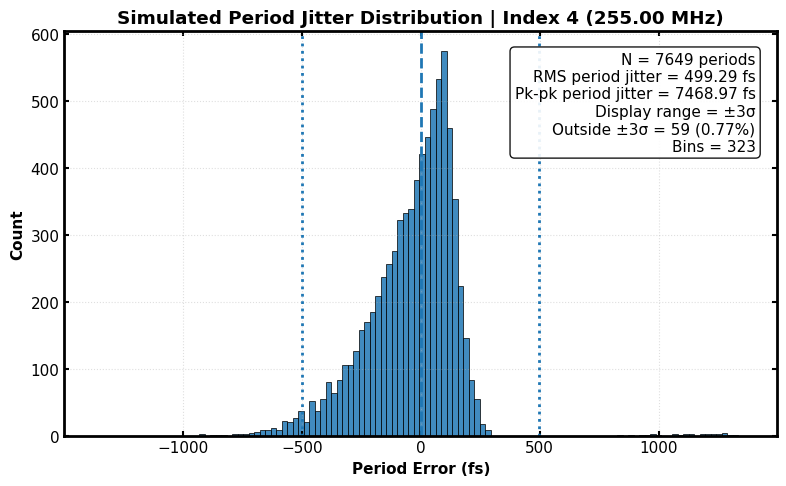

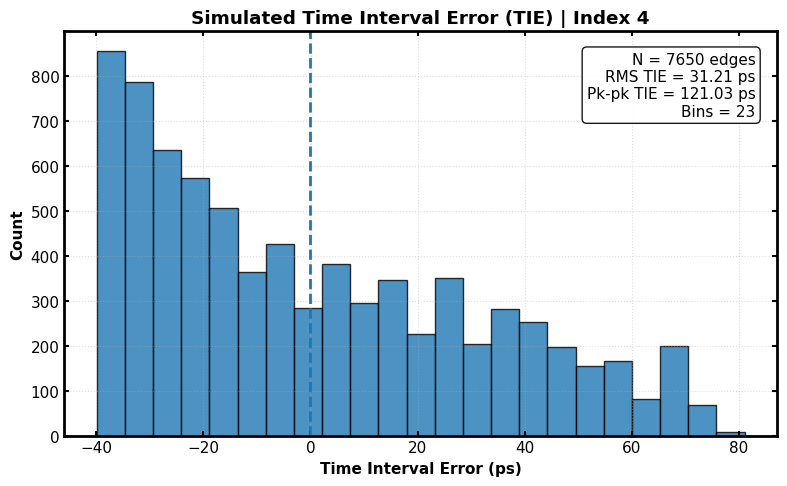


Generating TIE edge overlay...


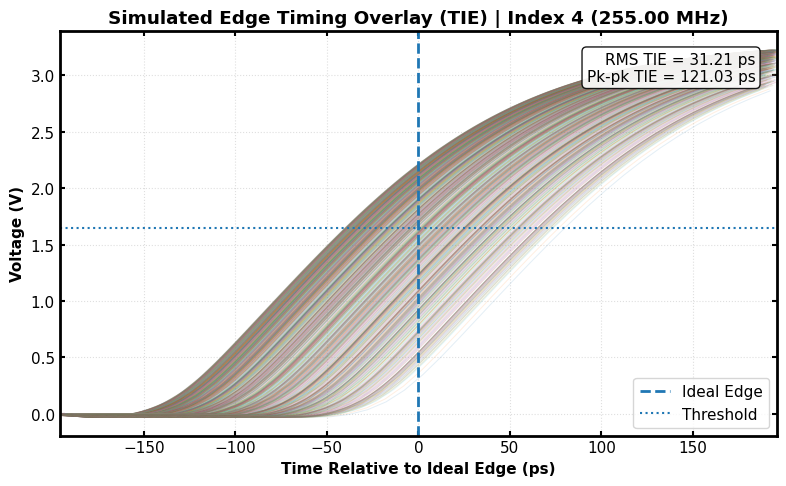



FINAL SIMULATION SUMMARY
Index                 : 4
Operating Frequency   : 255.0046 MHz
Period Samples        : 7649
RMS Period Jitter     : 499.2861 fs
Pk-Pk Period Jitter   : 7468.9657 fs
Histogram Bins        : 323
RMS TIE               : 31.2134 ps
Pk-Pk TIE             : 121.0329 ps
Max I/Q Phase Error   : 0.0002 deg
Phase Noise @ 1 MHz    : -92.32 dBc/Hz

Results directory:
/foss/designs/synchronos-chipathon-2026/designs/libs/scripts/pll_characterization/results/index_4_255p00_MHz


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import sys


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Select ONE testbench
# ------------------------------------------------------------

# =========================
# TB1
# =========================
#FILE_PATH = '../sim_data/tb1_3.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 13e-3
#STOP_TIME_THRESHOLD = 40.8e-3
#TESTBENCH_INDEX = 1


# =========================
# TB2
# =========================
#FILE_PATH = '../sim_data/tb2_7.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 71e-6
#STOP_TIME_THRESHOLD = 120e-6
#TESTBENCH_INDEX = 2


# =========================
# TB3
# =========================
#FILE_PATH = '../sim_data/tb3_4.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 85e-6
#STOP_TIME_THRESHOLD = 150e-6
#TESTBENCH_INDEX = 3


# =========================
# TB4
# =========================
FILE_PATH = '../sim_data/tb4.txt'
VCO_COLUMN_NAME = 'ck0'
LOCK_TIME_THRESHOLD = 120e-6
STOP_TIME_THRESHOLD = 150e-6
TESTBENCH_INDEX = 4


# =========================
# TB5
# =========================
#FILE_PATH = '../sim_data/tb5_3.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 10e-6
#STOP_TIME_THRESHOLD = 180e-6
#TESTBENCH_INDEX = 5


# ------------------------------------------------------------
# General configuration
# ------------------------------------------------------------

V_MID = 1.65

RESULTS_ROOT = Path("./results")

SAVE_FIGURES = True
SHOW_FIGURES = True

# Maximum number of traces in TIE overlay
MAX_TIE_OVERLAY_TRACES = 1000

# Histogram limits
MIN_HIST_BINS = 20
MAX_HIST_BINS = 400


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_rising_edges(v_sig, t_sig, threshold):
    """
    Extract rising-edge threshold crossing times.

    Linear interpolation is used between adjacent transient
    samples to improve crossing-time accuracy.
    """

    crossing_idx = np.where(
        (v_sig[:-1] < threshold) &
        (v_sig[1:] >= threshold)
    )[0]

    edges = []

    for idx in crossing_idx:

        t1 = t_sig[idx]
        t2 = t_sig[idx + 1]

        v1 = v_sig[idx]
        v2 = v_sig[idx + 1]

        if v2 == v1:
            continue

        t_cross = t1 + (
            (t2 - t1) *
            (threshold - v1) /
            (v2 - v1)
        )

        edges.append(t_cross)

    return np.asarray(edges)


def calculate_adjacent_phase(
    lead_edges,
    lag_edges,
    mean_period
):
    """
    Calculate average phase separation between adjacent
    quadrature clock phases.
    """

    phase_values = []

    for t_lead in lead_edges:

        future_edges = lag_edges[
            lag_edges > t_lead
        ]

        if len(future_edges) == 0:
            continue

        delta_t = (
            future_edges[0] -
            t_lead
        )

        phase_deg = (
            360.0 *
            delta_t /
            mean_period
        ) % 360.0

        phase_values.append(
            phase_deg
        )

    if len(phase_values) == 0:
        return np.nan

    return np.mean(
        phase_values
    )


def choose_frequency_unit(freq_hz):
    """
    Select convenient frequency display unit.
    """

    if freq_hz >= 1e9:
        return 1e9, 'GHz'

    elif freq_hz >= 1e6:
        return 1e6, 'MHz'

    elif freq_hz >= 1e3:
        return 1e3, 'kHz'

    else:
        return 1.0, 'Hz'


def choose_general_time_unit(seconds_value):
    """
    General-purpose time scale for TIE / waveform plots.
    """

    value = abs(seconds_value)

    if value >= 1e-3:
        return 1e3, 'ms'

    elif value >= 1e-6:
        return 1e6, 'µs'

    elif value >= 1e-9:
        return 1e9, 'ns'

    elif value >= 1e-12:
        return 1e12, 'ps'

    else:
        return 1e15, 'fs'


def choose_jitter_time_unit(rms_jitter):
    """
    Choose jitter plotting unit based primarily on RMS jitter.

    This prevents a few pk-pk outliers from forcing the
    histogram into an unnecessarily coarse unit.

    Examples:
        5.8 ns   -> ns
        1.7 ps   -> ps
        0.5 ps   -> fs
    """

    value = abs(rms_jitter)

    if value >= 1e-6:
        return 1e6, 'µs'

    elif value >= 1e-9:
        return 1e9, 'ns'

    elif value >= 1e-12:
        return 1e12, 'ps'

    else:
        return 1e15, 'fs'


def choose_histogram_bins_fd(
    data,
    min_bins=20,
    max_bins=MAX_HIST_BINS
):
    data = np.asarray(data)
    data = data[np.isfinite(data)]

    n = len(data)

    if n < 2:
        return min_bins

    data_range = np.max(data) - np.min(data)

    if data_range <= 0:
        return min_bins

    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25

    if iqr <= 0:
        bins = int(np.sqrt(n))
        return max(min_bins, min(max_bins, bins))

    bin_width = 2.0 * iqr / (n ** (1.0 / 3.0))

    if not np.isfinite(bin_width) or bin_width <= 0:
        bins = int(np.sqrt(n))
        return max(min_bins, min(max_bins, bins))

    bins = int(np.ceil(data_range / bin_width))

    return max(
        min_bins,
        min(max_bins, bins)
    )


def finish_figure(
    fig,
    filename
):
    """
    Save figure to current testbench folder and display it.
    """

    plt.tight_layout()

    if SAVE_FIGURES:

        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=300,
            transparent=True,
            bbox_inches='tight'
        )

    if SHOW_FIGURES:
        plt.show()

    else:
        plt.close(fig)


# ============================================================
# 3. LOAD SIMULATION DATA
# ============================================================

print("=" * 72)

print(
    f"PLL SIMULATION ANALYSIS - "
    f"INDEX {TESTBENCH_INDEX}"
)

print("=" * 72)

print(
    "\nLoading simulation data..."
)


try:

    df = pd.read_csv(
        FILE_PATH,
        sep=r'\s+'
    )

except FileNotFoundError:

    print(
        f"\nERROR: Could not find file:\n"
        f"{FILE_PATH}"
    )

    sys.exit()


# Make column names case-insensitive
df.columns = (
    df.columns
    .str.lower()
)


if 'time' not in df.columns:

    print(
        "ERROR: Column 'time' not found."
    )

    sys.exit()


vco_col = (
    VCO_COLUMN_NAME.lower()
)


if vco_col not in df.columns:

    print(
        f"ERROR: Column "
        f"'{VCO_COLUMN_NAME}' "
        f"not found."
    )

    sys.exit()


# ============================================================
# 4. SELECT STEADY-STATE / LOCKED REGION
# ============================================================

df = df[
    (df['time'] > LOCK_TIME_THRESHOLD) &
    (df['time'] < STOP_TIME_THRESHOLD)
].copy()


if df.empty:

    print(
        "\nERROR: No data available inside "
        "the selected steady-state window."
    )

    print(
        f"Start = "
        f"{LOCK_TIME_THRESHOLD:.6e} s"
    )

    print(
        f"Stop  = "
        f"{STOP_TIME_THRESHOLD:.6e} s"
    )

    sys.exit()


t = (
    df['time']
    .to_numpy()
)


v_ck0 = (
    df[vco_col]
    .to_numpy()
)


print(
    f"\nTransient samples in analysis window: "
    f"{len(t)}"
)


# ============================================================
# 5. DETECT QUADRATURE OUTPUTS
# ============================================================

quadrature_columns = [
    'ck90',
    'ck180',
    'ck270'
]


has_quadrature = all(
    col in df.columns
    for col in quadrature_columns
)


if has_quadrature:

    print(
        "Detected quadrature outputs: "
        "CK0, CK90, CK180, CK270"
    )

    v_ck90 = (
        df['ck90']
        .to_numpy()
    )

    v_ck180 = (
        df['ck180']
        .to_numpy()
    )

    v_ck270 = (
        df['ck270']
        .to_numpy()
    )

else:

    print(
        "Quadrature outputs not detected. "
        "Quadrature analysis will be skipped."
    )


# ============================================================
# 6. EXTRACT CK0 RISING EDGES
# ============================================================

print(
    "\nExtracting CK0 rising edges..."
)


edges_0 = get_rising_edges(
    v_ck0,
    t,
    V_MID
)


if len(edges_0) < 3:

    print(
        "ERROR: Too few CK0 rising edges "
        "were detected."
    )

    sys.exit()


print(
    f"Detected rising edges: "
    f"{len(edges_0)}"
)


# ============================================================
# 7. FREQUENCY / PERIOD ANALYSIS
# ============================================================

periods = np.diff(
    edges_0
)


mean_period = np.mean(
    periods
)


mean_frequency = (
    1.0 /
    mean_period
)


freq_scale, freq_unit = (
    choose_frequency_unit(
        mean_frequency
    )
)


freq_display = (
    mean_frequency /
    freq_scale
)


print(
    "\n--- CLOCK FREQUENCY ---"
)


print(
    f"Mean period: "
    f"{mean_period:.9e} s"
)


print(
    f"Mean frequency: "
    f"{freq_display:.4f} "
    f"{freq_unit}"
)


print(
    f"Number of periods: "
    f"{len(periods)}"
)


# ============================================================
# 8. CREATE DEDICATED OUTPUT FOLDER
# ============================================================

freq_folder_value = (
    f"{freq_display:.2f}"
    .replace('.', 'p')
)


OUTPUT_DIR = (
    RESULTS_ROOT /
    (
        f"index_{TESTBENCH_INDEX}_"
        f"{freq_folder_value}_"
        f"{freq_unit}"
    )
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    f"\nResults will be saved to:\n"
    f"{OUTPUT_DIR.resolve()}"
)


# ============================================================
# 9. PERIOD JITTER ANALYSIS
# ============================================================

# Period deviation from average period
period_error = (
    periods -
    mean_period
)


# RMS period jitter
rms_period_jitter = np.std(
    period_error,
    ddof=0
)


# Peak-to-peak period jitter
pp_period_jitter = np.ptp(
    period_error
)


# IMPORTANT:
# Unit chosen from RMS, not pk-pk.
period_jitter_scale, period_jitter_unit = (
    choose_jitter_time_unit(
        rms_period_jitter
    )
)


period_error_scaled = (
    period_error *
    period_jitter_scale
)


rms_period_jitter_scaled = (
    rms_period_jitter *
    period_jitter_scale
)


pp_period_jitter_scaled = (
    pp_period_jitter *
    period_jitter_scale
)


period_error_min = np.min(
    period_error_scaled
)


period_error_max = np.max(
    period_error_scaled
)


period_hist_bins = (
    choose_histogram_bins_fd(
        period_error_scaled
    )
)


print(
    "\n--- PERIOD JITTER ---"
)


print(
    f"RMS period jitter: "
    f"{rms_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Pk-pk period jitter: "
    f"{pp_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Minimum period error: "
    f"{period_error_min:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Maximum period error: "
    f"{period_error_max:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Automatic histogram bins: "
    f"{period_hist_bins}"
)


# ============================================================
# 10. TIME INTERVAL ERROR (TIE)
# ============================================================

edge_number = np.arange(
    len(edges_0)
)


# Ideal clock based on mean period
ideal_edges_raw = (
    edges_0[0] +
    edge_number *
    mean_period
)


tie_array = (
    edges_0 -
    ideal_edges_raw
)


# Remove constant TIE offset
tie_mean = np.mean(
    tie_array
)


tie_array = (
    tie_array -
    tie_mean
)


# Adjust ideal clock accordingly
ideal_edges_centered = (
    ideal_edges_raw +
    tie_mean
)


rms_tie = np.std(
    tie_array
)


pp_tie = np.ptp(
    tie_array
)


tie_scale, tie_unit = (
    choose_general_time_unit(
        max(
            rms_tie,
            pp_tie
        )
    )
)


tie_scaled = (
    tie_array *
    tie_scale
)


rms_tie_scaled = (
    rms_tie *
    tie_scale
)


pp_tie_scaled = (
    pp_tie *
    tie_scale
)


tie_hist_bins = (
    choose_histogram_bins_fd(
        tie_scaled
    )
)


print(
    "\n--- TIME INTERVAL ERROR ---"
)


print(
    f"RMS TIE: "
    f"{rms_tie_scaled:.4f} "
    f"{tie_unit}"
)


print(
    f"Pk-pk TIE: "
    f"{pp_tie_scaled:.4f} "
    f"{tie_unit}"
)


# ------------------------------------------------------------
# Detrended TIE for phase-noise calculation only
# ------------------------------------------------------------

tie_detrended = signal.detrend(
    tie_array,
    type='linear'
)


# ============================================================
# 11. QUADRATURE PHASE ANALYSIS
# ============================================================

phase_0_90 = np.nan
phase_90_180 = np.nan
phase_180_270 = np.nan
phase_270_0 = np.nan

max_phase_error = np.nan


if has_quadrature:

    print(
        "\nCalculating quadrature phase alignment..."
    )


    edges_90 = get_rising_edges(
        v_ck90,
        t,
        V_MID
    )


    edges_180 = get_rising_edges(
        v_ck180,
        t,
        V_MID
    )


    edges_270 = get_rising_edges(
        v_ck270,
        t,
        V_MID
    )


    phase_0_90 = calculate_adjacent_phase(
        edges_0,
        edges_90,
        mean_period
    )


    phase_90_180 = calculate_adjacent_phase(
        edges_90,
        edges_180,
        mean_period
    )


    phase_180_270 = calculate_adjacent_phase(
        edges_180,
        edges_270,
        mean_period
    )


    phase_270_0 = calculate_adjacent_phase(
        edges_270,
        edges_0,
        mean_period
    )


    phase_values = np.array([
        phase_0_90,
        phase_90_180,
        phase_180_270,
        phase_270_0
    ])


    phase_errors = np.abs(
        phase_values -
        90.0
    )


    max_phase_error = np.nanmax(
        phase_errors
    )


    print(
        "\n--- QUADRATURE PHASE RESULTS ---"
    )


    print(
        f"CK0 -> CK90:   "
        f"{phase_0_90:.4f} deg "
        f"(error "
        f"{abs(phase_0_90 - 90):.4f} deg)"
    )


    print(
        f"CK90 -> CK180: "
        f"{phase_90_180:.4f} deg "
        f"(error "
        f"{abs(phase_90_180 - 90):.4f} deg)"
    )


    print(
        f"CK180 -> CK270:"
        f"{phase_180_270:.4f} deg "
        f"(error "
        f"{abs(phase_180_270 - 90):.4f} deg)"
    )


    print(
        f"CK270 -> CK0:  "
        f"{phase_270_0:.4f} deg "
        f"(error "
        f"{abs(phase_270_0 - 90):.4f} deg)"
    )


    print(
        f"Maximum phase error: "
        f"{max_phase_error:.4f} deg"
    )


# ============================================================
# 12. PHASE NOISE ESTIMATE FROM TIE
# ============================================================

print(
    "\nEstimating phase noise from TIE..."
)


phase_sampling_frequency = (
    mean_frequency
)


# Time error -> phase error
#
# phi[n] = 2*pi*fc*TIE[n]
phase_error_rad = (
    tie_detrended *
    2.0 *
    np.pi *
    mean_frequency
)


if len(phase_error_rad) < 4:

    print(
        "ERROR: Not enough TIE samples "
        "for phase-noise PSD."
    )

    sys.exit()


nperseg = len(
    phase_error_rad
)


offset_freqs, phase_psd = signal.welch(
    phase_error_rad,
    fs=phase_sampling_frequency,
    window='hann',
    nperseg=nperseg,
    detrend=False,
    scaling='density'
)


# SSB phase noise approximation:
#
# L(f) = S_phi(f) / 2
phase_noise_dbc = (
    10.0 *
    np.log10(
        phase_psd / 2.0 +
        1e-30
    )
)


valid = (
    offset_freqs > 0
)


offset_freqs = (
    offset_freqs[
        valid
    ]
)


phase_noise_dbc = (
    phase_noise_dbc[
        valid
    ]
)


# ------------------------------------------------------------
# Choose phase-noise benchmark
# ------------------------------------------------------------

if mean_frequency < 1e6:

    target_offset = 1e3

else:

    target_offset = 1e6


benchmark_phase_noise = np.nan
benchmark_label = "N/A"


if (
    len(offset_freqs) > 0
    and
    target_offset <= offset_freqs[-1]
):

    nearest_idx = np.argmin(
        np.abs(
            offset_freqs -
            target_offset
        )
    )


    benchmark_phase_noise = (
        phase_noise_dbc[
            nearest_idx
        ]
    )


    if target_offset < 1e6:

        benchmark_label = (
            f"{target_offset / 1e3:.0f} kHz"
        )

    else:

        benchmark_label = (
            f"{target_offset / 1e6:.0f} MHz"
        )


    print(
        f"Phase noise @ "
        f"{benchmark_label}: "
        f"{benchmark_phase_noise:.2f} "
        f"dBc/Hz"
    )


else:

    print(
        "Benchmark phase-noise offset "
        "outside available PSD range."
    )


# ============================================================
# 13. MATPLOTLIB CONFIGURATION
# ============================================================

plt.rcParams.update({

    'axes.linewidth': 2,

    'axes.labelweight': 'bold',

    'font.weight': 'normal',

    'font.size': 11,

    'xtick.major.width': 1.5,

    'ytick.major.width': 1.5,

    'xtick.minor.width': 1.0,

    'ytick.minor.width': 1.0,

    'xtick.direction': 'in',

    'ytick.direction': 'in',

    'xtick.top': True,

    'ytick.right': True
})


# ============================================================
# 14. QUADRATURE WAVEFORM
# ============================================================

if has_quadrature:

    zoom_start = (
        t[-1] -
        3 *
        mean_period
    )


    zoom_mask = (
        t >= zoom_start
    )


    waveform_scale, waveform_unit = (
        choose_general_time_unit(
            3 *
            mean_period
        )
    )


    t_plot = (
        t[zoom_mask] -
        zoom_start
    ) * waveform_scale


    fig, ax = plt.subplots(
        figsize=(10, 4)
    )


    ax.plot(
        t_plot,
        v_ck0[zoom_mask],
        label='0° (I+)',
        linewidth=2
    )


    ax.plot(
        t_plot,
        v_ck90[zoom_mask],
        label='90° (Q+)',
        linewidth=2
    )


    ax.plot(
        t_plot,
        v_ck180[zoom_mask],
        label='180° (I−)',
        linewidth=2
    )


    ax.plot(
        t_plot,
        v_ck270[zoom_mask],
        label='270° (Q−)',
        linewidth=2
    )


    ax.set_title(
        (
            f"Steady-State Quadrature Phase Alignment | "
            f"Index {TESTBENCH_INDEX} "
            f"({freq_display:.2f} {freq_unit})"
        ),
        fontweight='bold'
    )


    ax.set_xlabel(
        f"Time ({waveform_unit})"
    )


    ax.set_ylabel(
        "Voltage (V)"
    )


    ax.grid(
        True,
        linestyle=':',
        alpha=0.4
    )


    ax.legend(
        loc='center left',
        bbox_to_anchor=(
            1.02,
            0.5
        )
    )


    finish_figure(
        fig,
        "quadrature_waveform.png"
    )


# ============================================================
# 15. PHASE-NOISE PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.semilogx(
    offset_freqs,
    phase_noise_dbc,
    linewidth=2
)


ax.set_title(
    (
        f"Simulated Phase Noise | "
        f"Index {TESTBENCH_INDEX} "
        f"({freq_display:.2f} {freq_unit})"
    ),
    fontweight='bold'
)


ax.set_xlabel(
    "Offset Frequency (Hz)"
)


ax.set_ylabel(
    "Phase Noise (dBc/Hz)"
)


ax.grid(
    True,
    which='both',
    linestyle=':',
    alpha=0.5
)


ax.set_ylim(
    top=0
)


if not np.isnan(
    benchmark_phase_noise
):

    ax.scatter(
        target_offset,
        benchmark_phase_noise,
        zorder=5
    )


    ax.annotate(
        (
            f"{benchmark_phase_noise:.2f} dBc/Hz\n"
            f"@ {benchmark_label}"
        ),
        xy=(
            target_offset,
            benchmark_phase_noise
        ),
        xytext=(
            15,
            15
        ),
        textcoords='offset points',
        arrowprops=dict(
            arrowstyle='->'
        )
    )


finish_figure(
    fig,
    "phase_noise.png"
)

# ============================================================
# 16. PERIOD-JITTER HISTOGRAM
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

# ------------------------------------------------------------
# Adaptive histogram
# ------------------------------------------------------------

ax.hist(
    period_error_scaled,
    bins=period_hist_bins,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.85
)

# Mean
ax.axvline(
    0,
    linestyle='--',
    linewidth=2,
    label='Mean'
)

# +/- 1 sigma
ax.axvline(
    rms_period_jitter_scaled,
    linestyle=':',
    linewidth=2,
    label='+1σ'
)

ax.axvline(
    -rms_period_jitter_scaled,
    linestyle=':',
    linewidth=2,
    label='−1σ'
)

# ------------------------------------------------------------
# Focus displayed frame to ±3σ
# ------------------------------------------------------------

sigma_display = (
    3.0 *
    rms_period_jitter_scaled
)

ax.set_xlim(
    -sigma_display,
    sigma_display
)

# Count samples outside displayed ±3σ range
outside_3sigma = np.sum(
    np.abs(period_error_scaled) >
    sigma_display
)

outside_3sigma_percent = (
    100.0 *
    outside_3sigma /
    len(period_error_scaled)
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    (
        f"Simulated Period Jitter Distribution | "
        f"Index {TESTBENCH_INDEX} "
        f"({freq_display:.2f} {freq_unit})"
    ),
    fontweight='bold'
)

ax.set_xlabel(
    f"Period Error ({period_jitter_unit})"
)

ax.set_ylabel(
    "Count"
)

ax.grid(
    True,
    linestyle=':',
    alpha=0.4
)

# ------------------------------------------------------------
# Result box
# ------------------------------------------------------------

jitter_text = (
    f"N = {len(period_error)} periods\n"
    f"RMS period jitter = "
    f"{rms_period_jitter_scaled:.2f} "
    f"{period_jitter_unit}\n"
    f"Pk-pk period jitter = "
    f"{pp_period_jitter_scaled:.2f} "
    f"{period_jitter_unit}\n"
    f"Display range = ±3σ\n"
    f"Outside ±3σ = "
    f"{outside_3sigma} "
    f"({outside_3sigma_percent:.2f}%)\n"
    f"Bins = {period_hist_bins}"
)

ax.text(
    0.97,
    0.95,
    jitter_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

finish_figure(
    fig,
    "period_jitter_histogram.png"
)

# ============================================================
# 17. TIE HISTOGRAM
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.hist(
    tie_scaled,
    bins=tie_hist_bins,
    edgecolor='black',
    alpha=0.8
)


ax.axvline(
    0,
    linestyle='--',
    linewidth=2
)


ax.set_title(
    (
        f"Simulated Time Interval Error (TIE) | "
        f"Index {TESTBENCH_INDEX}"
    ),
    fontweight='bold'
)


ax.set_xlabel(
    f"Time Interval Error ({tie_unit})"
)


ax.set_ylabel(
    "Count"
)


ax.grid(
    True,
    linestyle=':',
    alpha=0.4
)


tie_text = (

    f"N = {len(tie_array)} edges\n"

    f"RMS TIE = "
    f"{rms_tie_scaled:.2f} "
    f"{tie_unit}\n"

    f"Pk-pk TIE = "
    f"{pp_tie_scaled:.2f} "
    f"{tie_unit}\n"

    f"Bins = {tie_hist_bins}"
)


ax.text(
    0.97,
    0.95,
    tie_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)


finish_figure(
    fig,
    "tie_histogram.png"
)


# ============================================================
# 18. TIE EDGE-OVERLAY WAVEFORM
# ============================================================

print(
    "\nGenerating TIE edge overlay..."
)


overlay_half_window = max(
    1.2 *
    np.max(
        np.abs(
            tie_array
        )
    ),
    0.05 *
    mean_period
)


overlay_scale, overlay_unit = (
    choose_general_time_unit(
        overlay_half_window
    )
)


num_overlay_traces = min(
    len(edges_0),
    MAX_TIE_OVERLAY_TRACES
)


overlay_indices = np.linspace(
    1,
    len(edges_0) - 2,
    num_overlay_traces,
    dtype=int
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


for i in overlay_indices:

    ideal_edge = (
        ideal_edges_centered[i]
    )


    mask = (
        (t >= ideal_edge - overlay_half_window) &
        (t <= ideal_edge + overlay_half_window)
    )


    if not np.any(mask):
        continue


    t_relative = (
        t[mask] -
        ideal_edge
    ) * overlay_scale


    ax.plot(
        t_relative,
        v_ck0[mask],
        linewidth=0.7,
        alpha=0.12
    )


# Ideal edge
ax.axvline(
    0,
    linestyle='--',
    linewidth=2,
    label='Ideal Edge'
)


# Voltage crossing threshold
ax.axhline(
    V_MID,
    linestyle=':',
    linewidth=1.5,
    label='Threshold'
)


ax.set_title(
    (
        f"Simulated Edge Timing Overlay (TIE) | "
        f"Index {TESTBENCH_INDEX} "
        f"({freq_display:.2f} {freq_unit})"
    ),
    fontweight='bold'
)


ax.set_xlabel(
    f"Time Relative to Ideal Edge "
    f"({overlay_unit})"
)


ax.set_ylabel(
    "Voltage (V)"
)


ax.set_xlim(
    -overlay_half_window *
    overlay_scale,
    overlay_half_window *
    overlay_scale
)


ax.grid(
    True,
    linestyle=':',
    alpha=0.4
)


overlay_text = (

    f"RMS TIE = "
    f"{rms_tie_scaled:.2f} "
    f"{tie_unit}\n"

    f"Pk-pk TIE = "
    f"{pp_tie_scaled:.2f} "
    f"{tie_unit}"
)


ax.text(
    0.97,
    0.95,
    overlay_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)


ax.legend(
    loc='lower right'
)


finish_figure(
    fig,
    "tie_edge_overlay.png"
)


# ============================================================
# 19. SAVE PERIOD-JITTER RAW DATA
# ============================================================

period_jitter_df = pd.DataFrame({

    'period_number':
        np.arange(
            len(periods)
        ),

    'period_s':
        periods,

    'period_error_s':
        period_error,

    f'period_error_{period_jitter_unit}':
        period_error_scaled
})


period_jitter_df.to_csv(
    OUTPUT_DIR /
    "period_jitter_data.csv",
    index=False
)


# ============================================================
# 20. SAVE TIE RAW DATA
# ============================================================

tie_df = pd.DataFrame({

    'edge_number':
        edge_number,

    'actual_edge_time_s':
        edges_0,

    'ideal_edge_time_s':
        ideal_edges_centered,

    'tie_s':
        tie_array,

    f'tie_{tie_unit}':
        tie_scaled
})


tie_df.to_csv(
    OUTPUT_DIR /
    "tie_data.csv",
    index=False
)


# ============================================================
# 21. SAVE PHASE-NOISE RAW DATA
# ============================================================

phase_noise_df = pd.DataFrame({

    'offset_frequency_hz':
        offset_freqs,

    'phase_noise_dbc_per_hz':
        phase_noise_dbc
})


phase_noise_df.to_csv(
    OUTPUT_DIR /
    "phase_noise_data.csv",
    index=False
)


# ============================================================
# 22. SAVE SUMMARY AS TXT
# ============================================================

summary_path = (
    OUTPUT_DIR /
    "summary.txt"
)


with open(
    summary_path,
    'w',
    encoding='utf-8'
) as f:

    f.write(
        f"PLL Simulation Summary - "
        f"Index {TESTBENCH_INDEX}\n"
    )

    f.write(
        "=" * 60 +
        "\n\n"
    )


    f.write(
        f"Input File:\n"
        f"{FILE_PATH}\n\n"
    )


    f.write(
        f"Analysis Window:\n"
        f"{LOCK_TIME_THRESHOLD:.9e} s "
        f"to "
        f"{STOP_TIME_THRESHOLD:.9e} s\n\n"
    )


    f.write(
        f"Operating Frequency : "
        f"{freq_display:.6f} "
        f"{freq_unit}\n"
    )


    f.write(
        f"Mean Period         : "
        f"{mean_period:.9e} s\n"
    )


    f.write(
        f"Detected Edges      : "
        f"{len(edges_0)}\n"
    )


    f.write(
        f"Period Samples      : "
        f"{len(periods)}\n\n"
    )


    # --------------------------------------------------------
    # Period jitter
    # --------------------------------------------------------

    f.write(
        "PERIOD JITTER\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    f.write(
        f"Display Unit          : "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Histogram Bins        : "
        f"{period_hist_bins}\n"
    )


    f.write(
        f"RMS Period Jitter     : "
        f"{rms_period_jitter_scaled:.6f} "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Pk-Pk Period Jitter   : "
        f"{pp_period_jitter_scaled:.6f} "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Minimum Period Error  : "
        f"{period_error_min:.6f} "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Maximum Period Error  : "
        f"{period_error_max:.6f} "
        f"{period_jitter_unit}\n\n"
    )


    # --------------------------------------------------------
    # TIE
    # --------------------------------------------------------

    f.write(
        "TIME INTERVAL ERROR\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    f.write(
        f"RMS TIE              : "
        f"{rms_tie_scaled:.6f} "
        f"{tie_unit}\n"
    )


    f.write(
        f"Pk-Pk TIE            : "
        f"{pp_tie_scaled:.6f} "
        f"{tie_unit}\n\n"
    )


    # --------------------------------------------------------
    # Quadrature
    # --------------------------------------------------------

    if has_quadrature:

        f.write(
            "QUADRATURE PHASE ALIGNMENT\n"
        )

        f.write(
            "-" * 60 +
            "\n"
        )


        f.write(
            f"CK0 -> CK90          : "
            f"{phase_0_90:.6f} deg\n"
        )


        f.write(
            f"CK90 -> CK180        : "
            f"{phase_90_180:.6f} deg\n"
        )


        f.write(
            f"CK180 -> CK270       : "
            f"{phase_180_270:.6f} deg\n"
        )


        f.write(
            f"CK270 -> CK0         : "
            f"{phase_270_0:.6f} deg\n"
        )


        f.write(
            f"Maximum Phase Error  : "
            f"{max_phase_error:.6f} deg\n\n"
        )


    # --------------------------------------------------------
    # Phase noise
    # --------------------------------------------------------

    f.write(
        "PHASE NOISE\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    if not np.isnan(
        benchmark_phase_noise
    ):

        f.write(
            f"Phase Noise @ "
            f"{benchmark_label:<8} : "
            f"{benchmark_phase_noise:.3f} "
            f"dBc/Hz\n"
        )

    else:

        f.write(
            "Benchmark phase noise : "
            "Not available\n"
        )


# ============================================================
# 23. SAVE SUMMARY CSV
# ============================================================

summary_data = {

    'index':
        TESTBENCH_INDEX,

    'frequency_hz':
        mean_frequency,

    'mean_period_s':
        mean_period,

    'period_samples':
        len(periods),

    'rms_period_jitter_s':
        rms_period_jitter,

    'pkpk_period_jitter_s':
        pp_period_jitter,

    'min_period_error_s':
        np.min(
            period_error
        ),

    'max_period_error_s':
        np.max(
            period_error
        ),

    'rms_tie_s':
        rms_tie,

    'pkpk_tie_s':
        pp_tie,

    'max_phase_error_deg':
        max_phase_error,

    'phase_noise_offset_hz':
        target_offset,

    'phase_noise_dbc_hz':
        benchmark_phase_noise
}


pd.DataFrame(
    [summary_data]
).to_csv(
    OUTPUT_DIR /
    "summary.csv",
    index=False
)


# ============================================================
# 24. FINAL TERMINAL SUMMARY
# ============================================================

print(
    "\n"
)


print("=" * 72)

print(
    "FINAL SIMULATION SUMMARY"
)

print("=" * 72)


print(
    f"Index                 : "
    f"{TESTBENCH_INDEX}"
)


print(
    f"Operating Frequency   : "
    f"{freq_display:.4f} "
    f"{freq_unit}"
)


print(
    f"Period Samples        : "
    f"{len(periods)}"
)


print(
    f"RMS Period Jitter     : "
    f"{rms_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Pk-Pk Period Jitter   : "
    f"{pp_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Histogram Bins        : "
    f"{period_hist_bins}"
)


print(
    f"RMS TIE               : "
    f"{rms_tie_scaled:.4f} "
    f"{tie_unit}"
)


print(
    f"Pk-Pk TIE             : "
    f"{pp_tie_scaled:.4f} "
    f"{tie_unit}"
)


if has_quadrature:

    print(
        f"Max I/Q Phase Error   : "
        f"{max_phase_error:.4f} deg"
    )


if not np.isnan(
    benchmark_phase_noise
):

    print(
        f"Phase Noise @ "
        f"{benchmark_label:<8} : "
        f"{benchmark_phase_noise:.2f} "
        f"dBc/Hz"
    )


print(
    f"\nResults directory:\n"
    f"{OUTPUT_DIR.resolve()}"
)


print("=" * 72)

PLL SIMULATION ANALYSIS - INDEX 5

Loading simulation data...

Transient samples in analysis window: 16999999
Detected quadrature outputs: CK0, CK90, CK180, CK270

Extracting CK0 rising edges...
Detected rising edges: 51000

--- CLOCK FREQUENCY ---
Mean period: 3.333333274e-09 s
Mean frequency: 300.0000 MHz
Number of periods: 50999

Results will be saved to:
/foss/designs/synchronos-chipathon-2026/designs/libs/scripts/pll_characterization/results/index_5_300p00_MHz

VDD voltage            : 3.300000 V
Average supply current : 15.315876 mA
Average power          : 50.542389 mW

--- PERIOD JITTER ---
RMS period jitter: 1.5374 ps
Pk-pk period jitter: 8.0900 ps
Minimum period error: -7.4859 ps
Maximum period error: 0.6040 ps
Automatic histogram bins: 400

--- TIME INTERVAL ERROR ---
RMS TIE: 4.1974 ps
Pk-pk TIE: 28.0338 ps

Calculating quadrature phase alignment...

--- QUADRATURE PHASE RESULTS ---
CK0 -> CK90:   90.0003 deg (error 0.0003 deg)
CK90 -> CK180: 90.0029 deg (error 0.0029 deg)


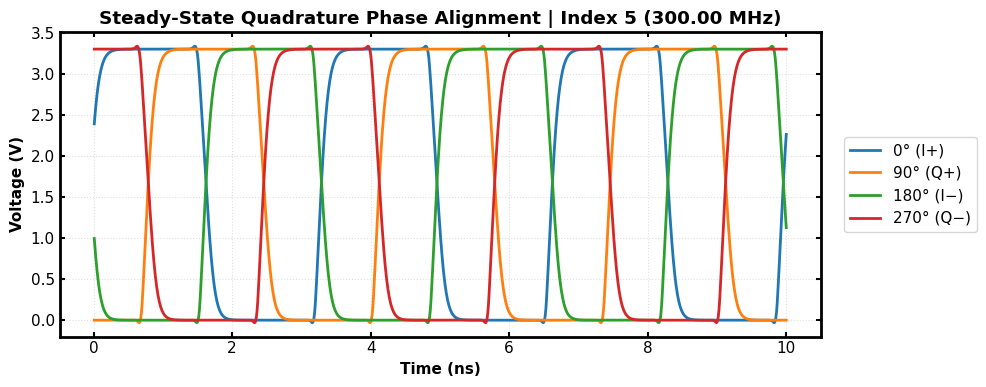

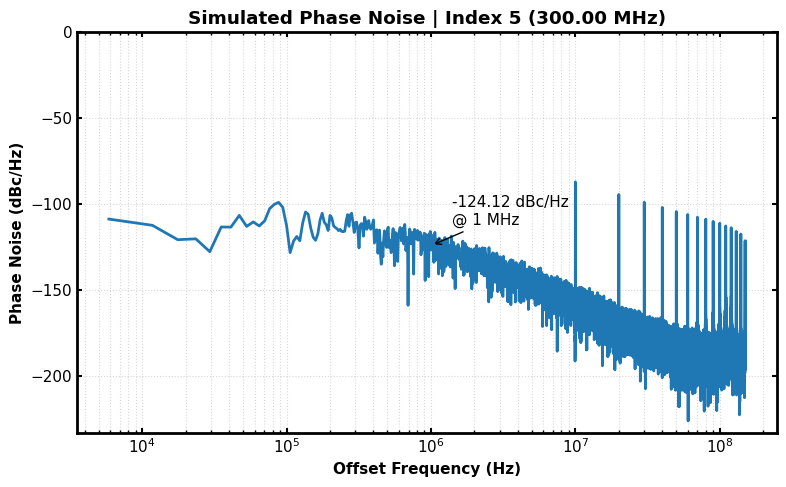

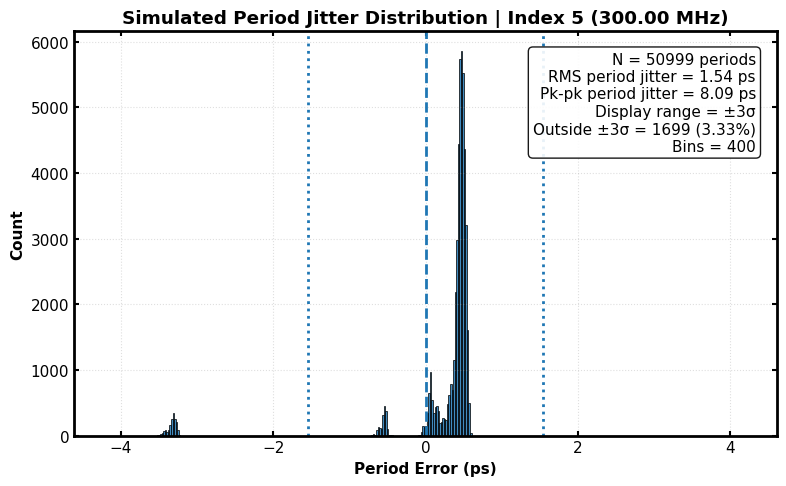

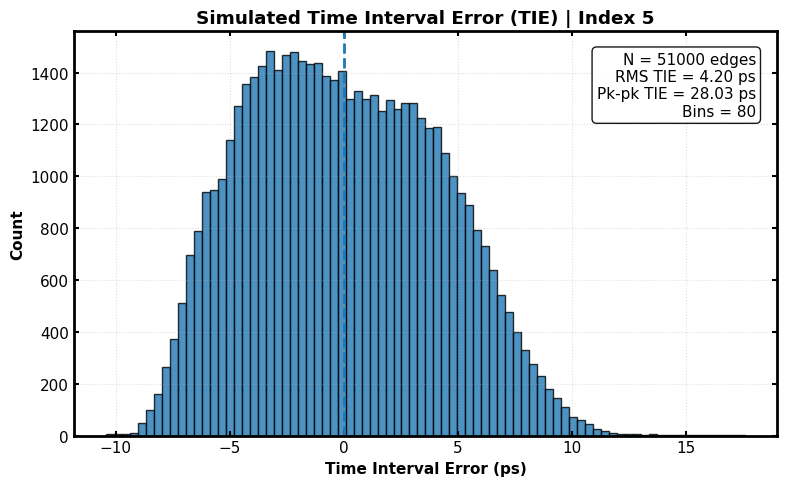


Generating TIE edge overlay...


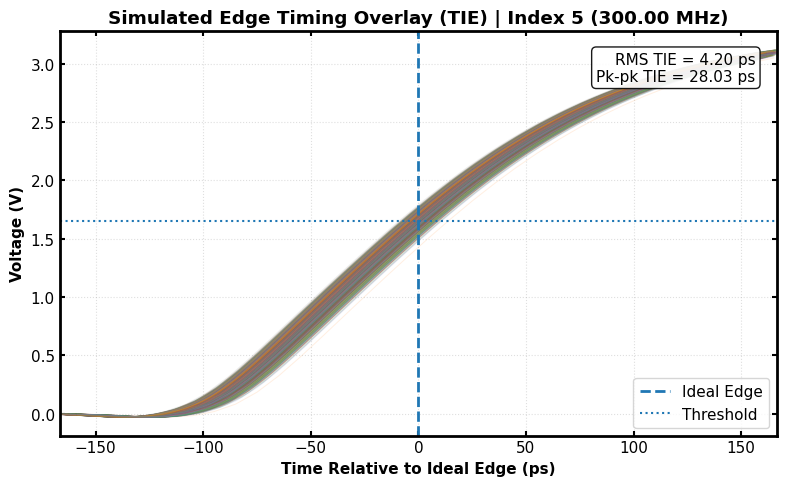



FINAL SIMULATION SUMMARY
Index                 : 5
Operating Frequency   : 300.0000 MHz
Period Samples        : 50999
RMS Period Jitter     : 1.5374 ps
Pk-Pk Period Jitter   : 8.0900 ps
Histogram Bins        : 400
RMS TIE               : 4.1974 ps
Pk-Pk TIE             : 28.0338 ps
Max I/Q Phase Error   : 0.0046 deg
Phase Noise @ 1 MHz    : -124.12 dBc/Hz
Average Supply Current: 15.315876 mA
Average Power         : 50.542389 mW

Results directory:
/foss/designs/synchronos-chipathon-2026/designs/libs/scripts/pll_characterization/results/index_5_300p00_MHz


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import sys


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Select ONE testbench
# ------------------------------------------------------------

# =========================
# TB1
# =========================
#FILE_PATH = '../sim_data/tb1_3.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 13e-3
#STOP_TIME_THRESHOLD = 40.8e-3
#TESTBENCH_INDEX = 1


# =========================
# TB2
# =========================
#FILE_PATH = '../sim_data/tb2_7.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 71e-6
#STOP_TIME_THRESHOLD = 120e-6
#TESTBENCH_INDEX = 2


# =========================
# TB3
# =========================
#FILE_PATH = '../sim_data/tb3_4.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 85e-6
#STOP_TIME_THRESHOLD = 150e-6
#TESTBENCH_INDEX = 3


# =========================
# TB4
# =========================
#FILE_PATH = '../sim_data/tb4.txt'
#VCO_COLUMN_NAME = 'ck0'
#LOCK_TIME_THRESHOLD = 120e-6
#STOP_TIME_THRESHOLD = 150e-6
#TESTBENCH_INDEX = 4


# =========================
# TB5
# =========================
FILE_PATH = '../sim_data/tb5_3.txt'
VCO_COLUMN_NAME = 'ck0'
LOCK_TIME_THRESHOLD = 10e-6
STOP_TIME_THRESHOLD = 180e-6
TESTBENCH_INDEX = 5


# ------------------------------------------------------------
# General configuration
# ------------------------------------------------------------

V_MID = 1.65

# Supply power calculation: Pavg = VDD * Iavg
VDD_VOLTAGE = 3.3
POWER_CURRENT_COLUMN = 'vmeas#branch'

# The current values in the supplied file are positive for consumed current.
# Change this to -1.0 if another simulator/testbench reports supply current
# as negative when the circuit draws power.
POWER_CURRENT_SIGN = 1.0

RESULTS_ROOT = Path("./results")

SAVE_FIGURES = True
SHOW_FIGURES = True

# Maximum number of traces in TIE overlay
MAX_TIE_OVERLAY_TRACES = 1000

# Histogram limits
MIN_HIST_BINS = 20
MAX_HIST_BINS = 400


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_rising_edges(v_sig, t_sig, threshold):
    """
    Extract rising-edge threshold crossing times.

    Linear interpolation is used between adjacent transient
    samples to improve crossing-time accuracy.
    """

    crossing_idx = np.where(
        (v_sig[:-1] < threshold) &
        (v_sig[1:] >= threshold)
    )[0]

    edges = []

    for idx in crossing_idx:

        t1 = t_sig[idx]
        t2 = t_sig[idx + 1]

        v1 = v_sig[idx]
        v2 = v_sig[idx + 1]

        if v2 == v1:
            continue

        t_cross = t1 + (
            (t2 - t1) *
            (threshold - v1) /
            (v2 - v1)
        )

        edges.append(t_cross)

    return np.asarray(edges)


def calculate_adjacent_phase(
    lead_edges,
    lag_edges,
    mean_period
):
    """
    Calculate average phase separation between adjacent
    quadrature clock phases.
    """

    phase_values = []

    for t_lead in lead_edges:

        future_edges = lag_edges[
            lag_edges > t_lead
        ]

        if len(future_edges) == 0:
            continue

        delta_t = (
            future_edges[0] -
            t_lead
        )

        phase_deg = (
            360.0 *
            delta_t /
            mean_period
        ) % 360.0

        phase_values.append(
            phase_deg
        )

    if len(phase_values) == 0:
        return np.nan

    return np.mean(
        phase_values
    )


def choose_frequency_unit(freq_hz):
    """
    Select convenient frequency display unit.
    """

    if freq_hz >= 1e9:
        return 1e9, 'GHz'

    elif freq_hz >= 1e6:
        return 1e6, 'MHz'

    elif freq_hz >= 1e3:
        return 1e3, 'kHz'

    else:
        return 1.0, 'Hz'


def choose_general_time_unit(seconds_value):
    """
    General-purpose time scale for TIE / waveform plots.
    """

    value = abs(seconds_value)

    if value >= 1e-3:
        return 1e3, 'ms'

    elif value >= 1e-6:
        return 1e6, 'µs'

    elif value >= 1e-9:
        return 1e9, 'ns'

    elif value >= 1e-12:
        return 1e12, 'ps'

    else:
        return 1e15, 'fs'


def choose_jitter_time_unit(rms_jitter):
    """
    Choose jitter plotting unit based primarily on RMS jitter.

    This prevents a few pk-pk outliers from forcing the
    histogram into an unnecessarily coarse unit.

    Examples:
        5.8 ns   -> ns
        1.7 ps   -> ps
        0.5 ps   -> fs
    """

    value = abs(rms_jitter)

    if value >= 1e-6:
        return 1e6, 'µs'

    elif value >= 1e-9:
        return 1e9, 'ns'

    elif value >= 1e-12:
        return 1e12, 'ps'

    else:
        return 1e15, 'fs'


def choose_histogram_bins_fd(
    data,
    min_bins=20,
    max_bins=MAX_HIST_BINS
):
    data = np.asarray(data)
    data = data[np.isfinite(data)]

    n = len(data)

    if n < 2:
        return min_bins

    data_range = np.max(data) - np.min(data)

    if data_range <= 0:
        return min_bins

    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25

    if iqr <= 0:
        bins = int(np.sqrt(n))
        return max(min_bins, min(max_bins, bins))

    bin_width = 2.0 * iqr / (n ** (1.0 / 3.0))

    if not np.isfinite(bin_width) or bin_width <= 0:
        bins = int(np.sqrt(n))
        return max(min_bins, min(max_bins, bins))

    bins = int(np.ceil(data_range / bin_width))

    return max(
        min_bins,
        min(max_bins, bins)
    )


def finish_figure(
    fig,
    filename
):
    """
    Save figure to current testbench folder and display it.
    """

    plt.tight_layout()

    if SAVE_FIGURES:

        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=300,
            transparent=True,
            bbox_inches='tight'
        )

    if SHOW_FIGURES:
        plt.show()

    else:
        plt.close(fig)


# ============================================================
# 3. LOAD SIMULATION DATA
# ============================================================

print("=" * 72)

print(
    f"PLL SIMULATION ANALYSIS - "
    f"INDEX {TESTBENCH_INDEX}"
)

print("=" * 72)

print(
    "\nLoading simulation data..."
)


try:

    df = pd.read_csv(
        FILE_PATH,
        sep=r'\s+'
    )

except FileNotFoundError:

    print(
        f"\nERROR: Could not find file:\n"
        f"{FILE_PATH}"
    )

    sys.exit()


# Make column names case-insensitive
df.columns = (
    df.columns
    .str.lower()
)


if 'time' not in df.columns:

    print(
        "ERROR: Column 'time' not found."
    )

    sys.exit()


vco_col = (
    VCO_COLUMN_NAME.lower()
)


if vco_col not in df.columns:

    print(
        f"ERROR: Column "
        f"'{VCO_COLUMN_NAME}' "
        f"not found."
    )

    sys.exit()


# ============================================================
# 4. SELECT STEADY-STATE / LOCKED REGION
# ============================================================

df = df[
    (df['time'] > LOCK_TIME_THRESHOLD) &
    (df['time'] < STOP_TIME_THRESHOLD)
].copy()


if df.empty:

    print(
        "\nERROR: No data available inside "
        "the selected steady-state window."
    )

    print(
        f"Start = "
        f"{LOCK_TIME_THRESHOLD:.6e} s"
    )

    print(
        f"Stop  = "
        f"{STOP_TIME_THRESHOLD:.6e} s"
    )

    sys.exit()


t = (
    df['time']
    .to_numpy()
)


v_ck0 = (
    df[vco_col]
    .to_numpy()
)


print(
    f"\nTransient samples in analysis window: "
    f"{len(t)}"
)


# ============================================================
# 5. DETECT QUADRATURE OUTPUTS
# ============================================================

quadrature_columns = [
    'ck90',
    'ck180',
    'ck270'
]


has_quadrature = all(
    col in df.columns
    for col in quadrature_columns
)


if has_quadrature:

    print(
        "Detected quadrature outputs: "
        "CK0, CK90, CK180, CK270"
    )

    v_ck90 = (
        df['ck90']
        .to_numpy()
    )

    v_ck180 = (
        df['ck180']
        .to_numpy()
    )

    v_ck270 = (
        df['ck270']
        .to_numpy()
    )

else:

    print(
        "Quadrature outputs not detected. "
        "Quadrature analysis will be skipped."
    )


# ============================================================
# 6. EXTRACT CK0 RISING EDGES
# ============================================================

print(
    "\nExtracting CK0 rising edges..."
)


edges_0 = get_rising_edges(
    v_ck0,
    t,
    V_MID
)


if len(edges_0) < 3:

    print(
        "ERROR: Too few CK0 rising edges "
        "were detected."
    )

    sys.exit()


print(
    f"Detected rising edges: "
    f"{len(edges_0)}"
)


# ============================================================
# 7. FREQUENCY / PERIOD ANALYSIS
# ============================================================

periods = np.diff(
    edges_0
)


mean_period = np.mean(
    periods
)


mean_frequency = (
    1.0 /
    mean_period
)


freq_scale, freq_unit = (
    choose_frequency_unit(
        mean_frequency
    )
)


freq_display = (
    mean_frequency /
    freq_scale
)


print(
    "\n--- CLOCK FREQUENCY ---"
)


print(
    f"Mean period: "
    f"{mean_period:.9e} s"
)


print(
    f"Mean frequency: "
    f"{freq_display:.4f} "
    f"{freq_unit}"
)


print(
    f"Number of periods: "
    f"{len(periods)}"
)


# ============================================================
# 8. CREATE DEDICATED OUTPUT FOLDER
# ============================================================

freq_folder_value = (
    f"{freq_display:.2f}"
    .replace('.', 'p')
)


OUTPUT_DIR = (
    RESULTS_ROOT /
    (
        f"index_{TESTBENCH_INDEX}_"
        f"{freq_folder_value}_"
        f"{freq_unit}"
    )
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    f"\nResults will be saved to:\n"
    f"{OUTPUT_DIR.resolve()}"
)


# ============================================================
# 8A. SUPPLY POWER CONSUMPTION
# ============================================================

power_current_col = POWER_CURRENT_COLUMN.lower()

has_power_data = power_current_col in df.columns


if has_power_data:

    power_df = pd.DataFrame({
        'time_s': df['time'],
        'raw_supply_current_a': df[power_current_col]
    })

    power_df = (
        power_df
        .apply(pd.to_numeric, errors='coerce')
        .dropna()
        .sort_values('time_s')
        .drop_duplicates(subset='time_s', keep='last')
        .reset_index(drop=True)
    )

    if len(power_df) >= 2:

        power_time = power_df['time_s'].to_numpy()
        supply_current = (
            POWER_CURRENT_SIGN *
            power_df['raw_supply_current_a'].to_numpy()
        )

        power_duration = (
            power_time[-1] -
            power_time[0]
        )

        if power_duration > 0:

            if hasattr(np, 'trapezoid'):
                integrate = np.trapezoid
            else:
                integrate = np.trapz

            average_supply_current = (
                integrate(supply_current, power_time) /
                power_duration
            )

            average_power = (
                VDD_VOLTAGE *
                average_supply_current
            )

            print(
                f"\nVDD voltage            : "
                f"{VDD_VOLTAGE:.6f} V"
            )

            print(
                f"Average supply current : "
                f"{average_supply_current * 1e3:.6f} mA"
            )

            print(
                f"Average power          : "
                f"{average_power * 1e3:.6f} mW"
            )

        else:

            has_power_data = False

            print(
                "WARNING: Power calculation skipped because "
                "the selected time window has zero duration."
            )

    else:

        has_power_data = False

        print(
            "WARNING: Power calculation skipped because fewer "
            "than two valid supply samples were found."
        )

else:

    print(
        "WARNING: Power calculation skipped. Required column "
        f"'{POWER_CURRENT_COLUMN}' was not found."
    )


# ============================================================
# 9. PERIOD JITTER ANALYSIS
# ============================================================

# Period deviation from average period
period_error = (
    periods -
    mean_period
)


# RMS period jitter
rms_period_jitter = np.std(
    period_error,
    ddof=0
)


# Peak-to-peak period jitter
pp_period_jitter = np.ptp(
    period_error
)


# IMPORTANT:
# Unit chosen from RMS, not pk-pk.
period_jitter_scale, period_jitter_unit = (
    choose_jitter_time_unit(
        rms_period_jitter
    )
)


period_error_scaled = (
    period_error *
    period_jitter_scale
)


rms_period_jitter_scaled = (
    rms_period_jitter *
    period_jitter_scale
)


pp_period_jitter_scaled = (
    pp_period_jitter *
    period_jitter_scale
)


period_error_min = np.min(
    period_error_scaled
)


period_error_max = np.max(
    period_error_scaled
)


period_hist_bins = (
    choose_histogram_bins_fd(
        period_error_scaled
    )
)


print(
    "\n--- PERIOD JITTER ---"
)


print(
    f"RMS period jitter: "
    f"{rms_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Pk-pk period jitter: "
    f"{pp_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Minimum period error: "
    f"{period_error_min:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Maximum period error: "
    f"{period_error_max:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Automatic histogram bins: "
    f"{period_hist_bins}"
)


# ============================================================
# 10. TIME INTERVAL ERROR (TIE)
# ============================================================

edge_number = np.arange(
    len(edges_0)
)


# Ideal clock based on mean period
ideal_edges_raw = (
    edges_0[0] +
    edge_number *
    mean_period
)


tie_array = (
    edges_0 -
    ideal_edges_raw
)


# Remove constant TIE offset
tie_mean = np.mean(
    tie_array
)


tie_array = (
    tie_array -
    tie_mean
)


# Adjust ideal clock accordingly
ideal_edges_centered = (
    ideal_edges_raw +
    tie_mean
)


rms_tie = np.std(
    tie_array
)


pp_tie = np.ptp(
    tie_array
)


tie_scale, tie_unit = (
    choose_general_time_unit(
        max(
            rms_tie,
            pp_tie
        )
    )
)


tie_scaled = (
    tie_array *
    tie_scale
)


rms_tie_scaled = (
    rms_tie *
    tie_scale
)


pp_tie_scaled = (
    pp_tie *
    tie_scale
)


tie_hist_bins = (
    choose_histogram_bins_fd(
        tie_scaled
    )
)


print(
    "\n--- TIME INTERVAL ERROR ---"
)


print(
    f"RMS TIE: "
    f"{rms_tie_scaled:.4f} "
    f"{tie_unit}"
)


print(
    f"Pk-pk TIE: "
    f"{pp_tie_scaled:.4f} "
    f"{tie_unit}"
)


# ------------------------------------------------------------
# Detrended TIE for phase-noise calculation only
# ------------------------------------------------------------

tie_detrended = signal.detrend(
    tie_array,
    type='linear'
)


# ============================================================
# 11. QUADRATURE PHASE ANALYSIS
# ============================================================

phase_0_90 = np.nan
phase_90_180 = np.nan
phase_180_270 = np.nan
phase_270_0 = np.nan

max_phase_error = np.nan


if has_quadrature:

    print(
        "\nCalculating quadrature phase alignment..."
    )


    edges_90 = get_rising_edges(
        v_ck90,
        t,
        V_MID
    )


    edges_180 = get_rising_edges(
        v_ck180,
        t,
        V_MID
    )


    edges_270 = get_rising_edges(
        v_ck270,
        t,
        V_MID
    )


    phase_0_90 = calculate_adjacent_phase(
        edges_0,
        edges_90,
        mean_period
    )


    phase_90_180 = calculate_adjacent_phase(
        edges_90,
        edges_180,
        mean_period
    )


    phase_180_270 = calculate_adjacent_phase(
        edges_180,
        edges_270,
        mean_period
    )


    phase_270_0 = calculate_adjacent_phase(
        edges_270,
        edges_0,
        mean_period
    )


    phase_values = np.array([
        phase_0_90,
        phase_90_180,
        phase_180_270,
        phase_270_0
    ])


    phase_errors = np.abs(
        phase_values -
        90.0
    )


    max_phase_error = np.nanmax(
        phase_errors
    )


    print(
        "\n--- QUADRATURE PHASE RESULTS ---"
    )


    print(
        f"CK0 -> CK90:   "
        f"{phase_0_90:.4f} deg "
        f"(error "
        f"{abs(phase_0_90 - 90):.4f} deg)"
    )


    print(
        f"CK90 -> CK180: "
        f"{phase_90_180:.4f} deg "
        f"(error "
        f"{abs(phase_90_180 - 90):.4f} deg)"
    )


    print(
        f"CK180 -> CK270:"
        f"{phase_180_270:.4f} deg "
        f"(error "
        f"{abs(phase_180_270 - 90):.4f} deg)"
    )


    print(
        f"CK270 -> CK0:  "
        f"{phase_270_0:.4f} deg "
        f"(error "
        f"{abs(phase_270_0 - 90):.4f} deg)"
    )


    print(
        f"Maximum phase error: "
        f"{max_phase_error:.4f} deg"
    )


# ============================================================
# 12. PHASE NOISE ESTIMATE FROM TIE
# ============================================================

print(
    "\nEstimating phase noise from TIE..."
)


phase_sampling_frequency = (
    mean_frequency
)


# Time error -> phase error
#
# phi[n] = 2*pi*fc*TIE[n]
phase_error_rad = (
    tie_detrended *
    2.0 *
    np.pi *
    mean_frequency
)


if len(phase_error_rad) < 4:

    print(
        "ERROR: Not enough TIE samples "
        "for phase-noise PSD."
    )

    sys.exit()


nperseg = len(
    phase_error_rad
)


offset_freqs, phase_psd = signal.welch(
    phase_error_rad,
    fs=phase_sampling_frequency,
    window='hann',
    nperseg=nperseg,
    detrend=False,
    scaling='density'
)


# SSB phase noise approximation:
#
# L(f) = S_phi(f) / 2
phase_noise_dbc = (
    10.0 *
    np.log10(
        phase_psd / 2.0 +
        1e-30
    )
)


valid = (
    offset_freqs > 0
)


offset_freqs = (
    offset_freqs[
        valid
    ]
)


phase_noise_dbc = (
    phase_noise_dbc[
        valid
    ]
)


# ------------------------------------------------------------
# Choose phase-noise benchmark
# ------------------------------------------------------------

if mean_frequency < 1e6:

    target_offset = 1e3

else:

    target_offset = 1e6


benchmark_phase_noise = np.nan
benchmark_label = "N/A"


if (
    len(offset_freqs) > 0
    and
    target_offset <= offset_freqs[-1]
):

    nearest_idx = np.argmin(
        np.abs(
            offset_freqs -
            target_offset
        )
    )


    benchmark_phase_noise = (
        phase_noise_dbc[
            nearest_idx
        ]
    )


    if target_offset < 1e6:

        benchmark_label = (
            f"{target_offset / 1e3:.0f} kHz"
        )

    else:

        benchmark_label = (
            f"{target_offset / 1e6:.0f} MHz"
        )


    print(
        f"Phase noise @ "
        f"{benchmark_label}: "
        f"{benchmark_phase_noise:.2f} "
        f"dBc/Hz"
    )


else:

    print(
        "Benchmark phase-noise offset "
        "outside available PSD range."
    )


# ============================================================
# 13. MATPLOTLIB CONFIGURATION
# ============================================================

plt.rcParams.update({

    'axes.linewidth': 2,

    'axes.labelweight': 'bold',

    'font.weight': 'normal',

    'font.size': 11,

    'xtick.major.width': 1.5,

    'ytick.major.width': 1.5,

    'xtick.minor.width': 1.0,

    'ytick.minor.width': 1.0,

    'xtick.direction': 'in',

    'ytick.direction': 'in',

    'xtick.top': True,

    'ytick.right': True
})


# ============================================================
# 14. QUADRATURE WAVEFORM
# ============================================================

if has_quadrature:

    zoom_start = (
        t[-1] -
        3 *
        mean_period
    )


    zoom_mask = (
        t >= zoom_start
    )


    waveform_scale, waveform_unit = (
        choose_general_time_unit(
            3 *
            mean_period
        )
    )


    t_plot = (
        t[zoom_mask] -
        zoom_start
    ) * waveform_scale


    fig, ax = plt.subplots(
        figsize=(10, 4)
    )


    ax.plot(
        t_plot,
        v_ck0[zoom_mask],
        label='0° (I+)',
        linewidth=2
    )


    ax.plot(
        t_plot,
        v_ck90[zoom_mask],
        label='90° (Q+)',
        linewidth=2
    )


    ax.plot(
        t_plot,
        v_ck180[zoom_mask],
        label='180° (I−)',
        linewidth=2
    )


    ax.plot(
        t_plot,
        v_ck270[zoom_mask],
        label='270° (Q−)',
        linewidth=2
    )


    ax.set_title(
        (
            f"Steady-State Quadrature Phase Alignment | "
            f"Index {TESTBENCH_INDEX} "
            f"({freq_display:.2f} {freq_unit})"
        ),
        fontweight='bold'
    )


    ax.set_xlabel(
        f"Time ({waveform_unit})"
    )


    ax.set_ylabel(
        "Voltage (V)"
    )


    ax.grid(
        True,
        linestyle=':',
        alpha=0.4
    )


    ax.legend(
        loc='center left',
        bbox_to_anchor=(
            1.02,
            0.5
        )
    )


    finish_figure(
        fig,
        "quadrature_waveform.png"
    )


# ============================================================
# 15. PHASE-NOISE PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.semilogx(
    offset_freqs,
    phase_noise_dbc,
    linewidth=2
)


ax.set_title(
    (
        f"Simulated Phase Noise | "
        f"Index {TESTBENCH_INDEX} "
        f"({freq_display:.2f} {freq_unit})"
    ),
    fontweight='bold'
)


ax.set_xlabel(
    "Offset Frequency (Hz)"
)


ax.set_ylabel(
    "Phase Noise (dBc/Hz)"
)


ax.grid(
    True,
    which='both',
    linestyle=':',
    alpha=0.5
)


ax.set_ylim(
    top=0
)


if not np.isnan(
    benchmark_phase_noise
):

    ax.scatter(
        target_offset,
        benchmark_phase_noise,
        zorder=5
    )


    ax.annotate(
        (
            f"{benchmark_phase_noise:.2f} dBc/Hz\n"
            f"@ {benchmark_label}"
        ),
        xy=(
            target_offset,
            benchmark_phase_noise
        ),
        xytext=(
            15,
            15
        ),
        textcoords='offset points',
        arrowprops=dict(
            arrowstyle='->'
        )
    )


finish_figure(
    fig,
    "phase_noise.png"
)

# ============================================================
# 16. PERIOD-JITTER HISTOGRAM
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

# ------------------------------------------------------------
# Adaptive histogram
# ------------------------------------------------------------

ax.hist(
    period_error_scaled,
    bins=period_hist_bins,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.85
)

# Mean
ax.axvline(
    0,
    linestyle='--',
    linewidth=2,
    label='Mean'
)

# +/- 1 sigma
ax.axvline(
    rms_period_jitter_scaled,
    linestyle=':',
    linewidth=2,
    label='+1σ'
)

ax.axvline(
    -rms_period_jitter_scaled,
    linestyle=':',
    linewidth=2,
    label='−1σ'
)

# ------------------------------------------------------------
# Focus displayed frame to ±3σ
# ------------------------------------------------------------

sigma_display = (
    3.0 *
    rms_period_jitter_scaled
)

ax.set_xlim(
    -sigma_display,
    sigma_display
)

# Count samples outside displayed ±3σ range
outside_3sigma = np.sum(
    np.abs(period_error_scaled) >
    sigma_display
)

outside_3sigma_percent = (
    100.0 *
    outside_3sigma /
    len(period_error_scaled)
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    (
        f"Simulated Period Jitter Distribution | "
        f"Index {TESTBENCH_INDEX} "
        f"({freq_display:.2f} {freq_unit})"
    ),
    fontweight='bold'
)

ax.set_xlabel(
    f"Period Error ({period_jitter_unit})"
)

ax.set_ylabel(
    "Count"
)

ax.grid(
    True,
    linestyle=':',
    alpha=0.4
)

# ------------------------------------------------------------
# Result box
# ------------------------------------------------------------

jitter_text = (
    f"N = {len(period_error)} periods\n"
    f"RMS period jitter = "
    f"{rms_period_jitter_scaled:.2f} "
    f"{period_jitter_unit}\n"
    f"Pk-pk period jitter = "
    f"{pp_period_jitter_scaled:.2f} "
    f"{period_jitter_unit}\n"
    f"Display range = ±3σ\n"
    f"Outside ±3σ = "
    f"{outside_3sigma} "
    f"({outside_3sigma_percent:.2f}%)\n"
    f"Bins = {period_hist_bins}"
)

ax.text(
    0.97,
    0.95,
    jitter_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

finish_figure(
    fig,
    "period_jitter_histogram.png"
)

# ============================================================
# 17. TIE HISTOGRAM
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.hist(
    tie_scaled,
    bins=tie_hist_bins,
    edgecolor='black',
    alpha=0.8
)


ax.axvline(
    0,
    linestyle='--',
    linewidth=2
)


ax.set_title(
    (
        f"Simulated Time Interval Error (TIE) | "
        f"Index {TESTBENCH_INDEX}"
    ),
    fontweight='bold'
)


ax.set_xlabel(
    f"Time Interval Error ({tie_unit})"
)


ax.set_ylabel(
    "Count"
)


ax.grid(
    True,
    linestyle=':',
    alpha=0.4
)


tie_text = (

    f"N = {len(tie_array)} edges\n"

    f"RMS TIE = "
    f"{rms_tie_scaled:.2f} "
    f"{tie_unit}\n"

    f"Pk-pk TIE = "
    f"{pp_tie_scaled:.2f} "
    f"{tie_unit}\n"

    f"Bins = {tie_hist_bins}"
)


ax.text(
    0.97,
    0.95,
    tie_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)


finish_figure(
    fig,
    "tie_histogram.png"
)


# ============================================================
# 18. TIE EDGE-OVERLAY WAVEFORM
# ============================================================

print(
    "\nGenerating TIE edge overlay..."
)


overlay_half_window = max(
    1.2 *
    np.max(
        np.abs(
            tie_array
        )
    ),
    0.05 *
    mean_period
)


overlay_scale, overlay_unit = (
    choose_general_time_unit(
        overlay_half_window
    )
)


num_overlay_traces = min(
    len(edges_0),
    MAX_TIE_OVERLAY_TRACES
)


overlay_indices = np.linspace(
    1,
    len(edges_0) - 2,
    num_overlay_traces,
    dtype=int
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


for i in overlay_indices:

    ideal_edge = (
        ideal_edges_centered[i]
    )


    mask = (
        (t >= ideal_edge - overlay_half_window) &
        (t <= ideal_edge + overlay_half_window)
    )


    if not np.any(mask):
        continue


    t_relative = (
        t[mask] -
        ideal_edge
    ) * overlay_scale


    ax.plot(
        t_relative,
        v_ck0[mask],
        linewidth=0.7,
        alpha=0.12
    )


# Ideal edge
ax.axvline(
    0,
    linestyle='--',
    linewidth=2,
    label='Ideal Edge'
)


# Voltage crossing threshold
ax.axhline(
    V_MID,
    linestyle=':',
    linewidth=1.5,
    label='Threshold'
)


ax.set_title(
    (
        f"Simulated Edge Timing Overlay (TIE) | "
        f"Index {TESTBENCH_INDEX} "
        f"({freq_display:.2f} {freq_unit})"
    ),
    fontweight='bold'
)


ax.set_xlabel(
    f"Time Relative to Ideal Edge "
    f"({overlay_unit})"
)


ax.set_ylabel(
    "Voltage (V)"
)


ax.set_xlim(
    -overlay_half_window *
    overlay_scale,
    overlay_half_window *
    overlay_scale
)


ax.grid(
    True,
    linestyle=':',
    alpha=0.4
)


overlay_text = (

    f"RMS TIE = "
    f"{rms_tie_scaled:.2f} "
    f"{tie_unit}\n"

    f"Pk-pk TIE = "
    f"{pp_tie_scaled:.2f} "
    f"{tie_unit}"
)


ax.text(
    0.97,
    0.95,
    overlay_text,
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)


ax.legend(
    loc='lower right'
)


finish_figure(
    fig,
    "tie_edge_overlay.png"
)


# ============================================================
# 19. SAVE PERIOD-JITTER RAW DATA
# ============================================================

period_jitter_df = pd.DataFrame({

    'period_number':
        np.arange(
            len(periods)
        ),

    'period_s':
        periods,

    'period_error_s':
        period_error,

    f'period_error_{period_jitter_unit}':
        period_error_scaled
})


period_jitter_df.to_csv(
    OUTPUT_DIR /
    "period_jitter_data.csv",
    index=False
)


# ============================================================
# 20. SAVE TIE RAW DATA
# ============================================================

tie_df = pd.DataFrame({

    'edge_number':
        edge_number,

    'actual_edge_time_s':
        edges_0,

    'ideal_edge_time_s':
        ideal_edges_centered,

    'tie_s':
        tie_array,

    f'tie_{tie_unit}':
        tie_scaled
})


tie_df.to_csv(
    OUTPUT_DIR /
    "tie_data.csv",
    index=False
)


# ============================================================
# 21. SAVE PHASE-NOISE RAW DATA
# ============================================================

phase_noise_df = pd.DataFrame({

    'offset_frequency_hz':
        offset_freqs,

    'phase_noise_dbc_per_hz':
        phase_noise_dbc
})


phase_noise_df.to_csv(
    OUTPUT_DIR /
    "phase_noise_data.csv",
    index=False
)


# ============================================================
# 22. SAVE SUMMARY AS TXT
# ============================================================

summary_path = (
    OUTPUT_DIR /
    "summary.txt"
)


with open(
    summary_path,
    'w',
    encoding='utf-8'
) as f:

    f.write(
        f"PLL Simulation Summary - "
        f"Index {TESTBENCH_INDEX}\n"
    )

    f.write(
        "=" * 60 +
        "\n\n"
    )


    f.write(
        f"Input File:\n"
        f"{FILE_PATH}\n\n"
    )


    f.write(
        f"Analysis Window:\n"
        f"{LOCK_TIME_THRESHOLD:.9e} s "
        f"to "
        f"{STOP_TIME_THRESHOLD:.9e} s\n\n"
    )


    f.write(
        f"Operating Frequency : "
        f"{freq_display:.6f} "
        f"{freq_unit}\n"
    )


    f.write(
        f"Mean Period         : "
        f"{mean_period:.9e} s\n"
    )


    f.write(
        f"Detected Edges      : "
        f"{len(edges_0)}\n"
    )


    f.write(
        f"Period Samples      : "
        f"{len(periods)}\n\n"
    )


    # --------------------------------------------------------
    # Period jitter
    # --------------------------------------------------------

    f.write(
        "PERIOD JITTER\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    f.write(
        f"Display Unit          : "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Histogram Bins        : "
        f"{period_hist_bins}\n"
    )


    f.write(
        f"RMS Period Jitter     : "
        f"{rms_period_jitter_scaled:.6f} "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Pk-Pk Period Jitter   : "
        f"{pp_period_jitter_scaled:.6f} "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Minimum Period Error  : "
        f"{period_error_min:.6f} "
        f"{period_jitter_unit}\n"
    )


    f.write(
        f"Maximum Period Error  : "
        f"{period_error_max:.6f} "
        f"{period_jitter_unit}\n\n"
    )


    # --------------------------------------------------------
    # TIE
    # --------------------------------------------------------

    f.write(
        "TIME INTERVAL ERROR\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    f.write(
        f"RMS TIE              : "
        f"{rms_tie_scaled:.6f} "
        f"{tie_unit}\n"
    )


    f.write(
        f"Pk-Pk TIE            : "
        f"{pp_tie_scaled:.6f} "
        f"{tie_unit}\n\n"
    )


    # --------------------------------------------------------
    # Quadrature
    # --------------------------------------------------------

    if has_quadrature:

        f.write(
            "QUADRATURE PHASE ALIGNMENT\n"
        )

        f.write(
            "-" * 60 +
            "\n"
        )


        f.write(
            f"CK0 -> CK90          : "
            f"{phase_0_90:.6f} deg\n"
        )


        f.write(
            f"CK90 -> CK180        : "
            f"{phase_90_180:.6f} deg\n"
        )


        f.write(
            f"CK180 -> CK270       : "
            f"{phase_180_270:.6f} deg\n"
        )


        f.write(
            f"CK270 -> CK0         : "
            f"{phase_270_0:.6f} deg\n"
        )


        f.write(
            f"Maximum Phase Error  : "
            f"{max_phase_error:.6f} deg\n\n"
        )


    # --------------------------------------------------------
    # Phase noise
    # --------------------------------------------------------

    f.write(
        "PHASE NOISE\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    if not np.isnan(
        benchmark_phase_noise
    ):

        f.write(
            f"Phase Noise @ "
            f"{benchmark_label:<8} : "
            f"{benchmark_phase_noise:.3f} "
            f"dBc/Hz\n"
        )

    else:

        f.write(
            "Benchmark phase noise : "
            "Not available\n"
        )


    # --------------------------------------------------------
    # Power consumption
    # --------------------------------------------------------

    f.write(
        "\nPOWER CONSUMPTION\n"
    )

    f.write(
        "-" * 60 +
        "\n"
    )


    if has_power_data:

        f.write(
            f"VDD Voltage           : "
            f"{VDD_VOLTAGE:.9e} V\n"
        )

        f.write(
            f"Current Column        : "
            f"{POWER_CURRENT_COLUMN}\n"
        )

        f.write(
            f"Average Current       : "
            f"{average_supply_current:.9e} A\n"
        )

        f.write(
            f"Average Power         : "
            f"{average_power:.9e} W\n"
        )

    else:

        f.write(
            "Power data            : Not available\n"
        )


# ============================================================
# 23. SAVE SUMMARY CSV
# ============================================================

summary_data = {

    'index':
        TESTBENCH_INDEX,

    'frequency_hz':
        mean_frequency,

    'mean_period_s':
        mean_period,

    'period_samples':
        len(periods),

    'rms_period_jitter_s':
        rms_period_jitter,

    'pkpk_period_jitter_s':
        pp_period_jitter,

    'min_period_error_s':
        np.min(
            period_error
        ),

    'max_period_error_s':
        np.max(
            period_error
        ),

    'rms_tie_s':
        rms_tie,

    'pkpk_tie_s':
        pp_tie,

    'max_phase_error_deg':
        max_phase_error,

    'phase_noise_offset_hz':
        target_offset,

    'phase_noise_dbc_hz':
        benchmark_phase_noise,

    'vdd_voltage_v':
        VDD_VOLTAGE,

    'average_supply_current_a':
        (
            average_supply_current
            if has_power_data
            else np.nan
        ),

    'average_power_w':
        (
            average_power
            if has_power_data
            else np.nan
        )
}


pd.DataFrame(
    [summary_data]
).to_csv(
    OUTPUT_DIR /
    "summary.csv",
    index=False
)


# ============================================================
# 24. FINAL TERMINAL SUMMARY
# ============================================================

print(
    "\n"
)


print("=" * 72)

print(
    "FINAL SIMULATION SUMMARY"
)

print("=" * 72)


print(
    f"Index                 : "
    f"{TESTBENCH_INDEX}"
)


print(
    f"Operating Frequency   : "
    f"{freq_display:.4f} "
    f"{freq_unit}"
)


print(
    f"Period Samples        : "
    f"{len(periods)}"
)


print(
    f"RMS Period Jitter     : "
    f"{rms_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Pk-Pk Period Jitter   : "
    f"{pp_period_jitter_scaled:.4f} "
    f"{period_jitter_unit}"
)


print(
    f"Histogram Bins        : "
    f"{period_hist_bins}"
)


print(
    f"RMS TIE               : "
    f"{rms_tie_scaled:.4f} "
    f"{tie_unit}"
)


print(
    f"Pk-Pk TIE             : "
    f"{pp_tie_scaled:.4f} "
    f"{tie_unit}"
)


if has_quadrature:

    print(
        f"Max I/Q Phase Error   : "
        f"{max_phase_error:.4f} deg"
    )


if not np.isnan(
    benchmark_phase_noise
):

    print(
        f"Phase Noise @ "
        f"{benchmark_label:<8} : "
        f"{benchmark_phase_noise:.2f} "
        f"dBc/Hz"
    )


if has_power_data:

    print(
        f"Average Supply Current: "
        f"{average_supply_current * 1e3:.6f} mA"
    )

    print(
        f"Average Power         : "
        f"{average_power * 1e3:.6f} mW"
    )


print(
    f"\nResults directory:\n"
    f"{OUTPUT_DIR.resolve()}"
)


print("=" * 72)
